# PreFlood_DW v6.0 — Interactive Analysis

Data Lakehouse for flood prediction in the Mondego river basin.

| Section | Description | Source Script |
|---------|-------------|---------------|
| 0 | Setup & Config | — |
| 1 | Explore Gold Layer | — |
| 2 | Spatial Proximity | `build_spatial_proximity.py` |
| 3 | Feature Engineering | `flood_ml.py` |
| 4 | Flood Clustering | `flood_ml.py` |
| 5 | Forecast Training | `forecast_ml.py` |
| 6 | Predict Now | `predict_now.py` |
| 7 | Visualization Suite | — |
| 8 | Flood Labeling (v6) | `flood_labeling.py` |
| 9 | LSTM Flood Classifier (v6) | `lstm_flood.py` |
| 10 | Risk Classification (v6) | `risk_classifier.py` |

---
## Section 0: Setup & Config

In [73]:
import os
import sys
import math
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyodbc
from datetime import datetime, timedelta

import contextily as ctx
from matplotlib.patches import FancyArrowPatch

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, mean_absolute_error,
                             mean_squared_error, r2_score)
from sklearn.model_selection import TimeSeriesSplit
from scipy.spatial import KDTree

import hdbscan
import lightgbm as lgb
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

SCRIPTS_DIR = os.path.join(os.getcwd(), 'Scripts')
if SCRIPTS_DIR not in sys.path:
    sys.path.insert(0, SCRIPTS_DIR)

from preflood_config import DB_NAME, get_conn

print('Setup OK —', datetime.now().strftime('%Y-%m-%d %H:%M'))

Setup OK — 2026-06-07 18:13


In [74]:
NATURAL_STATIONS = [229, 232, 233, 234]
DAM_STATIONS = [223, 224, 225, 226, 228, 230, 235]
ALL_SNIRH_STATIONS = NATURAL_STATIONS + DAM_STATIONS
FORECAST_HORIZONS = [1, 3, 6, 12, 24]
MODEL_VERSION = 'v6.0'

PARAM_ALIAS = {
    '1843': 'NIVEL_INST', '1845': 'NIVEL_MED_DIA', '1850': 'CAUDAL_MED_DIA',
    '3212219030': 'CAUDAL_DESC_DIA', '354895424': 'CAUDAL_AFLUENTE_DIA',
    'tp': 'PRECIPITACAO', 't2m': 'TEMP_2M',
    'swvl1': 'SOLO_UM_L1', 'swvl2': 'SOLO_UM_L2',
    'swvl3': 'SOLO_UM_L3', 'swvl4': 'SOLO_UM_L4', 'sp': 'PRESSAO_SUPERFICIE',
}

SNIRH_PARAMS = ['1843', '1845', '1850', '3212219030', '354895424']
ERA5_PARAMS = ['tp', 't2m', 'swvl1', 'swvl2', 'sp']
IPMA_PARAMS = ['prec', 'temp', 'press']

MODELS_DIR = os.path.join(os.getcwd(), 'Models')

print('Config loaded')
print('  Natural stations:', NATURAL_STATIONS)
print('  Dam stations:', DAM_STATIONS)
print('  Models dir:', MODELS_DIR)

Config loaded
  Natural stations: [229, 232, 233, 234]
  Dam stations: [223, 224, 225, 226, 228, 230, 235]
  Models dir: c:\ProjetoDW\V4\Models


In [75]:
def sql_query(conn, query, params=None):
    cur = conn.cursor()
    if params:
        cur.execute(query, params)
    else:
        cur.execute(query)
    cols = [desc[0] for desc in cur.description]
    rows = cur.fetchall()
    return pd.DataFrame.from_records(rows, columns=cols)

def sql_scalar(conn, query):
    cur = conn.cursor()
    cur.execute(query)
    return cur.fetchone()[0]

conn = get_conn()
print('Connected to', DB_NAME)

Connected to PreFlood_DW


---
## Section 1: Explore Gold Layer

,sistema_origem,total_facts,stations,parameters
0,ERA5,7720118,8,7
1,SNIRH,618681,14,5
2,IPMA,15763,193,8



Total facts: 8,354,562


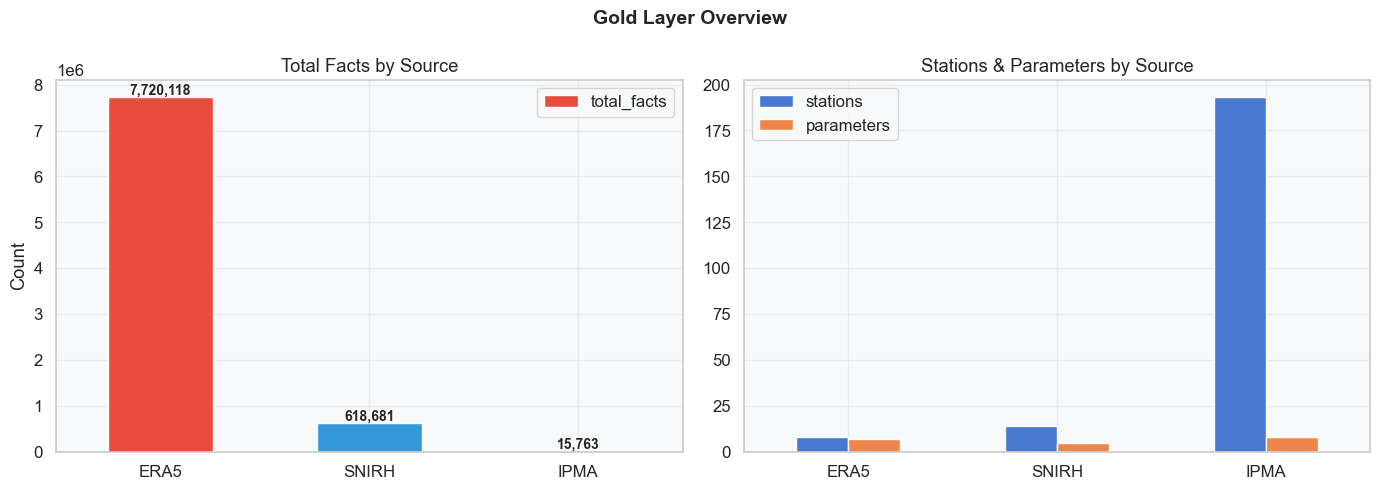

In [4]:
fact_counts = sql_query(conn, """
    SELECT e.sistema_origem, COUNT(*) as total_facts,
           COUNT(DISTINCT e.estacao_sk) as stations,
           COUNT(DISTINCT p.parametro_sk) as parameters
    FROM gold.fact_medicao f
    JOIN gold.dim_estacao e ON f.estacao_sk = e.estacao_sk
    JOIN gold.dim_parametro p ON f.parametro_sk = p.parametro_sk
    GROUP BY e.sistema_origem
    ORDER BY total_facts DESC
""")
display(fact_counts)

total = sql_scalar(conn, 'SELECT COUNT(*) FROM gold.fact_medicao')
print(f'\nTotal facts: {total:,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_src = {'SNIRH': '#3498db', 'IPMA': '#2ecc71', 'ERA5': '#e74c3c'}
fact_counts.plot(kind='bar', x='sistema_origem', y='total_facts', ax=axes[0],
                 color=[colors_src.get(s, '#888') for s in fact_counts['sistema_origem']])
axes[0].set_title('Total Facts by Source')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

fact_counts.plot(kind='bar', x='sistema_origem', y=['stations', 'parameters'], ax=axes[1])
axes[1].set_title('Stations & Parameters by Source')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Gold Layer Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

,sistema_origem,first_obs,last_obs,span_days
0,IPMA,2026-06-05 21:00:00,2026-06-06 20:00:00,1
1,SNIRH,2010-06-06 00:00:00,2026-06-06 23:00:00,5844
2,ERA5,2010-06-06 00:00:00,2026-05-30 23:00:00,5837


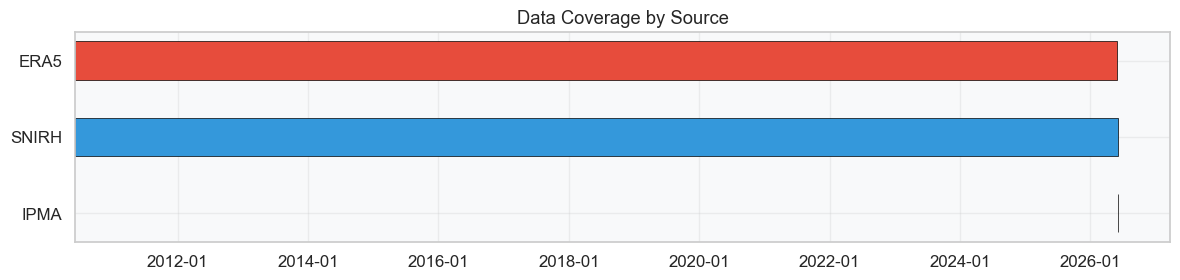

In [5]:
date_range = sql_query(conn, """
    SELECT e.sistema_origem,
           MIN(t.data_hora) as first_obs,
           MAX(t.data_hora) as last_obs,
           DATEDIFF(DAY, MIN(t.data_hora), MAX(t.data_hora)) as span_days
    FROM gold.fact_medicao f
    JOIN gold.dim_estacao e ON f.estacao_sk = e.estacao_sk
    JOIN gold.dim_tempo t ON f.tempo_sk = t.tempo_sk
    GROUP BY e.sistema_origem
""")
display(date_range)

fig, ax = plt.subplots(figsize=(12, 3))
colors_bar = {'SNIRH': '#3498db', 'IPMA': '#2ecc71', 'ERA5': '#e74c3c'}
for _, row in date_range.iterrows():
    src = row['sistema_origem']
    start = pd.to_datetime(row['first_obs'])
    end = pd.to_datetime(row['last_obs'])
    y_pos = list(date_range['sistema_origem']).index(src)
    ax.barh(y_pos, (end - start).days, left=start, height=0.5,
            color=colors_bar.get(src, '#888'), edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(date_range)))
ax.set_yticklabels(date_range['sistema_origem'])
ax.set_title('Data Coverage by Source')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

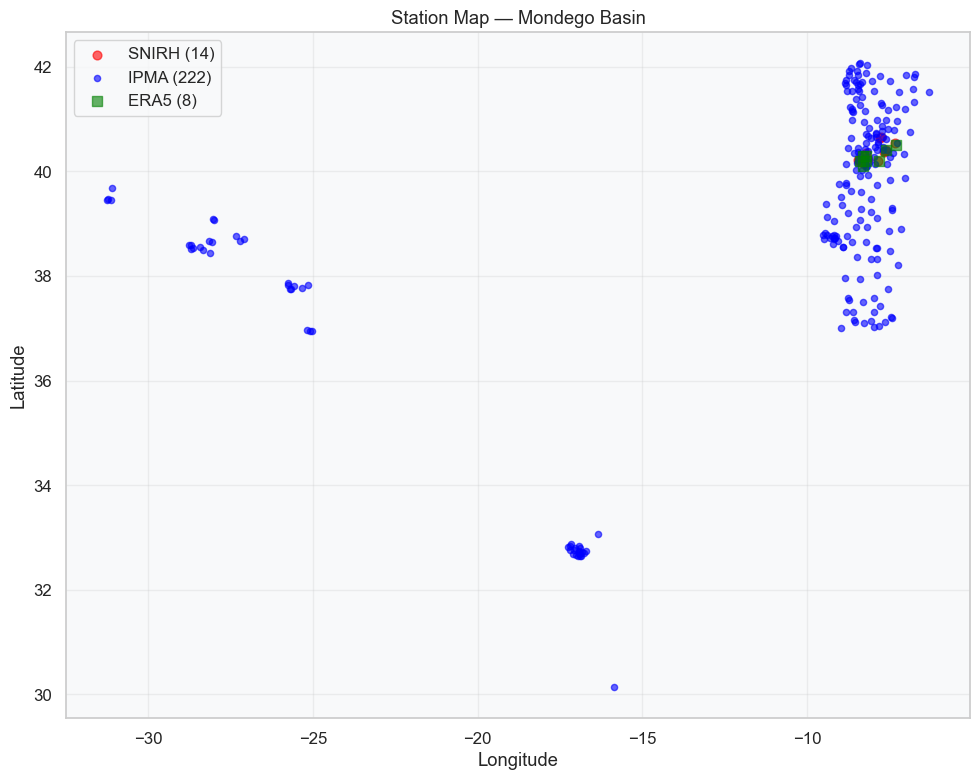

In [6]:
stations = sql_query(conn, """
    SELECT estacao_sk, estacao_id, estacao_nome, sistema_origem,
           latitude, longitude, bacia_codigo, ativa
    FROM gold.dim_estacao
    ORDER BY sistema_origem, estacao_sk
""")

fig, ax = plt.subplots(figsize=(10, 8))
colors = {'SNIRH': 'red', 'IPMA': 'blue', 'ERA5': 'green'}
for src in ['SNIRH', 'IPMA', 'ERA5']:
    mask = stations['sistema_origem'] == src
    sub = stations[mask]
    ax.scatter(sub['longitude'], sub['latitude'],
               c=colors[src], label=f'{src} ({len(sub)})',
               alpha=0.6, s=40 if src == 'SNIRH' else (20 if src == 'IPMA' else 60),
               marker='s' if src == 'ERA5' else 'o')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Station Map — Mondego Basin')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
params = sql_query(conn, """
    SELECT parametro_sk, parametro_id, parametro_nome, parametro_codigo,
           categoria, unidade_medida, sistema_origem, granularidade
    FROM gold.dim_parametro
    ORDER BY sistema_origem, parametro_sk
""")
display(params.style.set_caption('dim_parametro'))

,parametro_sk,parametro_id,parametro_nome,parametro_codigo,categoria,unidade_medida,sistema_origem,granularidade
0,14,51,Temperature 2m,t2m,Meteorologica,K,ERA5,HORARIA
1,15,52,Dewpoint 2m,d2m,Meteorologica,K,ERA5,HORARIA
2,16,53,Total Precipitation,tp,Meteorologica,m,ERA5,HORARIA
3,17,54,Surface Pressure,sp,Meteorologica,Pa,ERA5,HORARIA
4,18,55,Skin Temperature,skt,Meteorologica,K,ERA5,HORARIA
5,19,56,Snow Depth,sde,Meteorologica,m,ERA5,HORARIA
6,20,57,Soil Temperature L1,stl1,Solo,K,ERA5,HORARIA
7,21,58,Soil Temperature L2,stl2,Solo,K,ERA5,HORARIA
8,22,59,Soil Temperature L3,stl3,Solo,K,ERA5,HORARIA
9,23,60,Soil Temperature L4,stl4,Solo,K,ERA5,HORARIA


,tbl,cnt
0,ml.results,49904
1,ml.flood_risk_current,3
2,ml.forecast_predictions,30
3,ml.forecast_metrics,20
4,ml.model_metrics,3
5,ctl.map_spatial_proximity,708
6,ctl.ml_models,32
7,ctl.ml_risk_thresholds,4
8,logs.ETL_Log,23
9,quarentena.ETL_Quarentena,18022


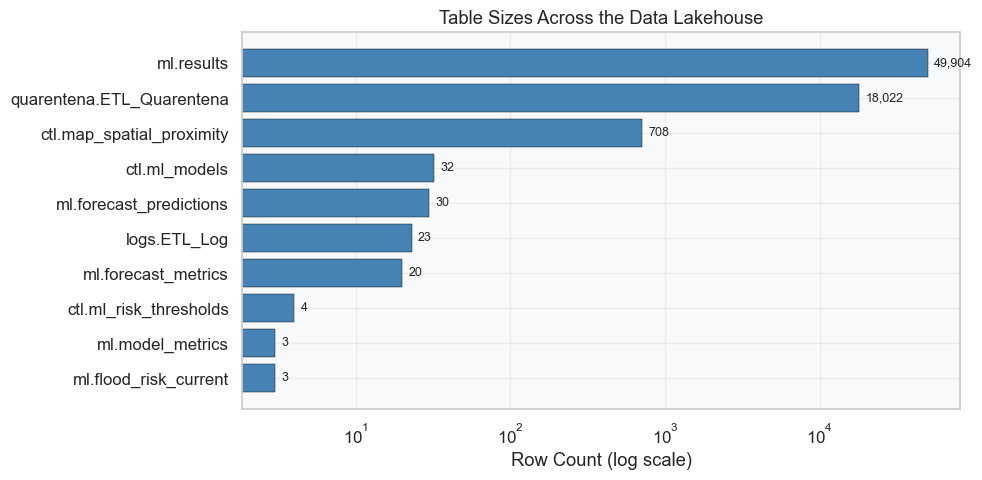

In [8]:
ml_counts = sql_query(conn, """
    SELECT 'ml.results' as tbl, COUNT(*) as cnt FROM ml.results
    UNION ALL SELECT 'ml.flood_risk_current', COUNT(*) FROM ml.flood_risk_current
    UNION ALL SELECT 'ml.forecast_predictions', COUNT(*) FROM ml.forecast_predictions
    UNION ALL SELECT 'ml.forecast_metrics', COUNT(*) FROM ml.forecast_metrics
    UNION ALL SELECT 'ml.model_metrics', COUNT(*) FROM ml.model_metrics
    UNION ALL SELECT 'ctl.map_spatial_proximity', COUNT(*) FROM ctl.map_spatial_proximity
    UNION ALL SELECT 'ctl.ml_models', COUNT(*) FROM ctl.ml_models
    UNION ALL SELECT 'ctl.ml_risk_thresholds', COUNT(*) FROM ctl.ml_risk_thresholds
    UNION ALL SELECT 'logs.ETL_Log', COUNT(*) FROM logs.ETL_Log
    UNION ALL SELECT 'quarentena.ETL_Quarentena', COUNT(*) FROM quarentena.ETL_Quarentena
""")
display(ml_counts.style.set_caption('Table Row Counts'))

fig, ax = plt.subplots(figsize=(10, 5))
ml_plot = ml_counts.sort_values('cnt', ascending=True)
bars = ax.barh(ml_plot['tbl'], ml_plot['cnt'], color='steelblue', edgecolor='black', linewidth=0.3)
ax.set_xscale('log')
ax.set_xlabel('Row Count (log scale)')
ax.set_title('Table Sizes Across the Data Lakehouse')
for bar in bars:
    w = bar.get_width()
    ax.text(w * 1.1, bar.get_y() + bar.get_height()/2, f'{int(w):,}',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 2: Spatial Proximity

Maps IPMA and SNIRH stations to their nearest ERA5 grid points using KDTree.

In [9]:
era5_st = stations[stations['sistema_origem'] == 'ERA5'].dropna(subset=['latitude', 'longitude'])
ipma_st = stations[stations['sistema_origem'] == 'IPMA'].dropna(subset=['latitude', 'longitude'])
snirh_st = stations[stations['sistema_origem'] == 'SNIRH'].dropna(subset=['latitude', 'longitude'])

print(f'ERA5: {len(era5_st)} grid points')
print(f'IPMA: {len(ipma_st)} stations')
print(f'SNIRH: {len(snirh_st)} stations')

avg_lat = math.radians(era5_st['latitude'].mean())
cos_lat = math.cos(avg_lat)

era5_coords = np.column_stack([
    era5_st['latitude'].values * 111.0,
    era5_st['longitude'].values * 111.0 * cos_lat,
])
tree = KDTree(era5_coords)

def find_nearest(src_df, label, k=3):
    src_coords = np.column_stack([
        src_df['latitude'].values * 111.0,
        src_df['longitude'].values * 111.0 * cos_lat,
    ])
    dists, idxs = tree.query(src_coords, k=min(k, len(era5_st)))
    rows = []
    for i in range(len(src_df)):
        for rank in range(min(k, len(era5_st))):
            eidx = idxs[i, rank]
            rows.append({
                'source_sk': int(src_df.iloc[i]['estacao_sk']),
                'source_name': src_df.iloc[i]['estacao_nome'],
                'era5_sk': int(era5_st.iloc[eidx]['estacao_sk']),
                'distance_km': float(dists[i, rank]),
                'rank': rank + 1,
            })
    return pd.DataFrame(rows)

snirh_prox = find_nearest(snirh_st, 'SNIRH')
ipma_prox = find_nearest(ipma_st, 'IPMA')

display(snirh_prox[snirh_prox['rank'] == 1].style.set_caption('SNIRH → ERA5 Nearest'))

ERA5: 8 grid points
IPMA: 222 stations
SNIRH: 14 stations


,source_sk,source_name,era5_sk,distance_km,rank
0,223,AÇUDE PONTE COIMBRA (12G/01AE),238,3.824831,1
3,224,ALBUFEIRA DA AGUIEIRA (R.E.) (11H/01A),242,4.558086,1
6,225,ALBUFEIRA DO ALTO CEIRA (R.E.) (12J/01A),240,4.050678,1
9,226,ALBUFEIRA DO CALDEIRÃO (R.E.) (10M/01A),244,4.886603,1
12,227,ALBUFEIRA DE FAGILDE (10K/01A),243,30.724096,1
15,228,ALBUFEIRA DE FRONHAS (R.E.) (12I/01A),239,5.828600,1
18,229,GEVIM (13H/04H),237,5.617177,1
21,230,ALBUFEIRA DA LAGOA COMPRIDA (R.E.) (11L/03A),243,5.760896,1
24,231,ALBUFEIRA DO LAGOACHO (R.E.) (11L/01A),243,2.298631,1
27,232,MOINHOS DE PEPIM (10K/04H),243,30.481018,1


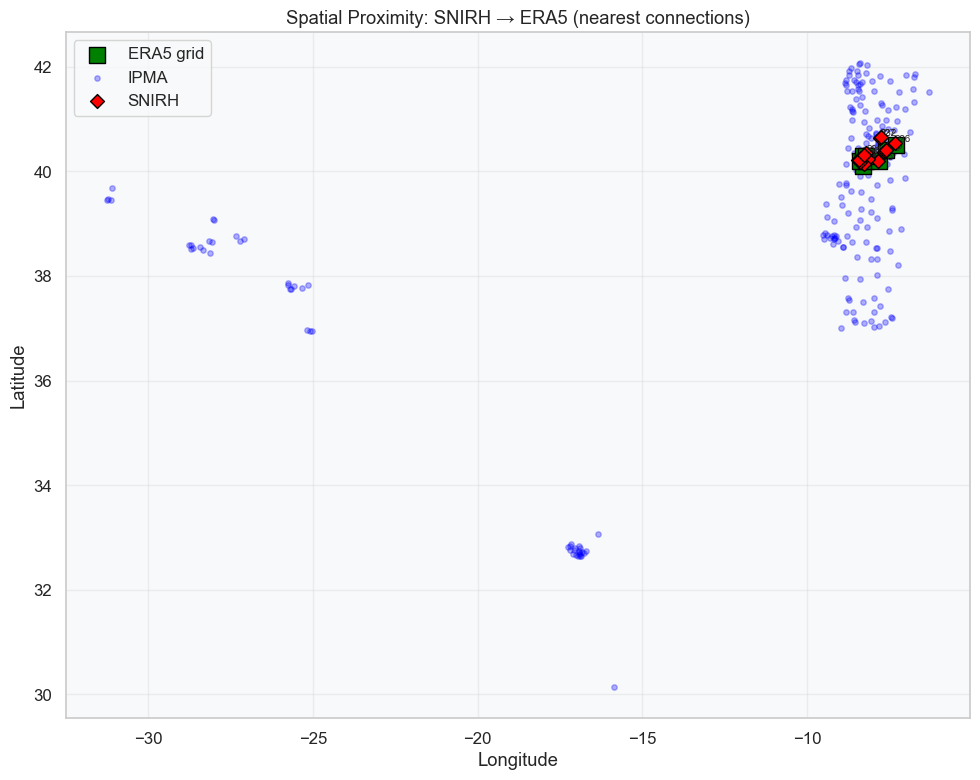

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(era5_st['longitude'], era5_st['latitude'],
           c='green', s=120, marker='s', label='ERA5 grid', zorder=3, edgecolors='black')
ax.scatter(ipma_st['longitude'], ipma_st['latitude'],
           c='blue', s=15, alpha=0.3, label='IPMA')
ax.scatter(snirh_st['longitude'], snirh_st['latitude'],
           c='red', s=50, marker='D', label='SNIRH', zorder=4, edgecolors='black')

for _, row in snirh_prox[snirh_prox['rank'] == 1].iterrows():
    src = snirh_st[snirh_st['estacao_sk'] == row['source_sk']].iloc[0]
    tgt = era5_st[era5_st['estacao_sk'] == row['era5_sk']].iloc[0]
    ax.plot([src['longitude'], tgt['longitude']],
            [src['latitude'], tgt['latitude']],
            'k--', alpha=0.4, linewidth=0.8)

for _, row in snirh_st.iterrows():
    ax.annotate(str(int(row['estacao_sk'])),
                (row['longitude'], row['latitude']),
                fontsize=7, ha='left', va='bottom')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Proximity: SNIRH → ERA5 (nearest connections)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 3: Feature Engineering

Extract data from Gold for natural river stations, pivot by parameter, compute lagged and derived features.

In [11]:
all_params = SNIRH_PARAMS + ERA5_PARAMS
ph = ','.join(['?'] * len(all_params))
sk_ph = ','.join(['?'] * len(NATURAL_STATIONS))

raw = sql_query(conn, """
    SELECT e.estacao_sk, e.estacao_nome, t.data_hora, t.ano, t.mes, t.hora,
           p.parametro_codigo, f.valor
    FROM gold.fact_medicao f
    JOIN gold.dim_estacao e ON f.estacao_sk = e.estacao_sk
    JOIN gold.dim_tempo t ON f.tempo_sk = t.tempo_sk
    JOIN gold.dim_parametro p ON f.parametro_sk = p.parametro_sk
    WHERE e.estacao_sk IN (""" + sk_ph + """)
    AND p.parametro_codigo IN (""" + ph + """)
""", NATURAL_STATIONS + all_params)

print(f'Raw rows: {len(raw):,}')
display(raw.head())

Raw rows: 395,646


,estacao_sk,estacao_nome,data_hora,ano,mes,hora,parametro_codigo,valor
0,233,PONTE CABOUCO (12G/02H),2010-06-06,2010,6,0,1850,0.01
1,232,MOINHOS DE PEPIM (10K/04H),2010-06-06,2010,6,0,1843,1.21
2,229,GEVIM (13H/04H),2010-06-06,2010,6,0,1843,2.00
3,233,PONTE CABOUCO (12G/02H),2010-06-06,2010,6,0,1845,0.08
4,229,GEVIM (13H/04H),2010-06-06,2010,6,0,1845,2.02


In [12]:
raw['data_hora'] = pd.to_datetime(raw['data_hora'])
raw.dropna(subset=['valor'], inplace=True)

pivot = raw.pivot_table(
    index=['estacao_sk', 'estacao_nome', 'data_hora', 'ano', 'mes', 'hora'],
    columns='parametro_codigo', values='valor', aggfunc='first'
).reset_index()
pivot = pivot.rename(columns=PARAM_ALIAS)
pivot = pivot.sort_values(['estacao_sk', 'data_hora']).reset_index(drop=True)

print(f'Pivot shape: {pivot.shape}')
display(pivot.head())

Pivot shape: (375834, 9)


parametro_codigo,estacao_sk,estacao_nome,data_hora,ano,mes,hora,NIVEL_INST,NIVEL_MED_DIA,CAUDAL_MED_DIA
0,229,GEVIM (13H/04H),2010-06-06 00:00:00,2010,6,0,2.00,2.02,NaN
1,229,GEVIM (13H/04H),2010-06-06 01:00:00,2010,6,1,2.00,NaN,NaN
2,229,GEVIM (13H/04H),2010-06-06 02:00:00,2010,6,2,2.00,NaN,NaN
3,229,GEVIM (13H/04H),2010-06-06 03:00:00,2010,6,3,2.00,NaN,NaN
4,229,GEVIM (13H/04H),2010-06-06 04:00:00,2010,6,4,2.02,NaN,NaN


In [13]:
SAMPLE_SIZE = 50000

if len(pivot) > SAMPLE_SIZE:
    n_per = SAMPLE_SIZE // len(NATURAL_STATIONS)
    parts = []
    for sk in NATURAL_STATIONS:
        sub = pivot[pivot['estacao_sk'] == sk]
        if len(sub) > n_per:
            sub = sub.sample(n=n_per, random_state=42)
        parts.append(sub)
    pivot = pd.concat(parts).sort_values('data_hora').reset_index(drop=True)
    print(f'Sampled to {len(pivot):,} rows')

print(f'Working shape: {pivot.shape}')

Sampled to 50,000 rows
Working shape: (50000, 9)


In [14]:
def compute_features(df):
    result_frames = []
    for sk in NATURAL_STATIONS:
        mask = df['estacao_sk'] == sk
        station = df[mask].copy().sort_values('data_hora')
        if 'NIVEL_INST' not in station.columns:
            continue

        nivel = station['NIVEL_INST']

        for w in [1, 3, 6, 12, 24]:
            station[f'taxa_subida_{w}h'] = (nivel - nivel.shift(w)) / w

        for w in [3, 6, 12, 24]:
            r = nivel.rolling(window=w, min_periods=1)
            station[f'nivel_rmean_{w}h'] = r.mean()
            station[f'nivel_rstd_{w}h'] = r.std()
            station[f'nivel_rmax_{w}h'] = r.max()

        if 'PRECIPITACAO' in station.columns:
            precip = station['PRECIPITACAO'].fillna(0)
            for w in [6, 12, 24, 48]:
                station[f'precip_accum_{w}h'] = precip.rolling(window=w, min_periods=1).sum()

        if 'SOLO_UM_L1' in station.columns:
            soil = station['SOLO_UM_L1'].fillna(0)
            soil_max = soil.max()
            station['soil_saturacao_ratio'] = soil / soil_max if soil_max > 0 else 0

        if 'TEMP_2M' in station.columns:
            station['temp_delta_6h'] = station['TEMP_2M'] - station['TEMP_2M'].shift(6)

        if 'PRESSAO_SUPERFICIE' in station.columns:
            station['pressao_delta_6h'] = station['PRESSAO_SUPERFICIE'] - station['PRESSAO_SUPERFICIE'].shift(6)

        station['hour_sin'] = np.sin(2 * np.pi * station['hora'] / 24)
        station['hour_cos'] = np.cos(2 * np.pi * station['hora'] / 24)
        station['month_sin'] = np.sin(2 * np.pi * station['mes'] / 12)
        station['month_cos'] = np.cos(2 * np.pi * station['mes'] / 12)

        result_frames.append(station)

    return pd.concat(result_frames, axis=0).reset_index(drop=True)

df_features = compute_features(pivot)
print(f'Features computed: {df_features.shape}')

Features computed: (50000, 30)


In [15]:
feature_keywords = [
    'taxa_subida', 'nivel_rmean', 'nivel_rstd', 'nivel_rmax',
    'precip_accum', 'soil_saturacao', 'temp_delta', 'pressao_delta',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'SOLO_UM_L1', 'SOLO_UM_L2', 'TEMP_2M', 'PRESSAO_SUPERFICIE', 'NIVEL_INST',
]

selected = [c for c in df_features.columns
            if any(kw in c for kw in feature_keywords)
            and df_features[c].notna().sum() > 100
            and df_features[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

print(f'Selected features: {len(selected)}')
print(selected)

Selected features: 22
['NIVEL_INST', 'taxa_subida_1h', 'taxa_subida_3h', 'taxa_subida_6h', 'taxa_subida_12h', 'taxa_subida_24h', 'nivel_rmean_3h', 'nivel_rstd_3h', 'nivel_rmax_3h', 'nivel_rmean_6h', 'nivel_rstd_6h', 'nivel_rmax_6h', 'nivel_rmean_12h', 'nivel_rstd_12h', 'nivel_rmax_12h', 'nivel_rmean_24h', 'nivel_rstd_24h', 'nivel_rmax_24h', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


---
## Section 4: Flood Clustering

KMeans + IsolationForest + HDBSCAN for anomaly detection and risk scoring.

In [16]:
valid = df_features[selected].replace([np.inf, -np.inf], np.nan).dropna()
valid_idx = valid.index
X = valid.values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

split_idx = int(0.8 * len(X_scaled))
X_train, X_val = X_scaled[:split_idx], X_scaled[split_idx:]

print(f'Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}')
print(f'Features: {X_train.shape[1]}')

Train: 39,923  |  Val: 9,981
Features: 22


Elbow k=5 (inertia=3934497)


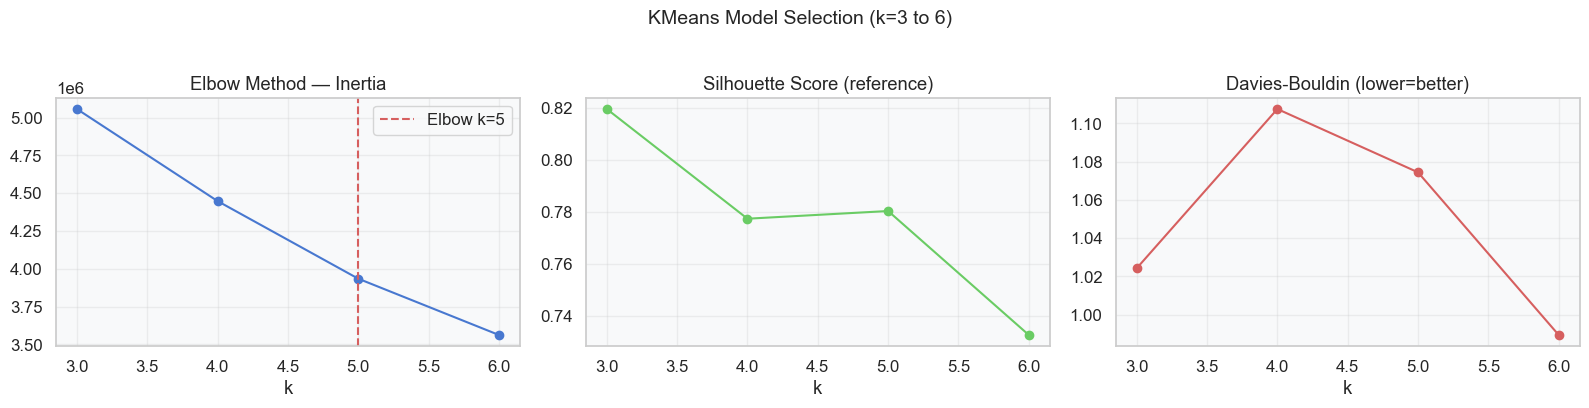

In [17]:
K_MIN, K_MAX = 3, 6
k_range = range(K_MIN, K_MAX + 1)
inertias, silhouettes, ch_scores, db_scores = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X_train)
    inertias.append(km.inertia_)
    if len(set(labels_km)) > 1:
        silhouettes.append(silhouette_score(X_train, labels_km, sample_size=min(10000, len(X_train))))
        ch_scores.append(calinski_harabasz_score(X_train, labels_km))
        db_scores.append(davies_bouldin_score(X_train, labels_km))
    else:
        silhouettes.append(0)
        ch_scores.append(0)
        db_scores.append(10)

def find_elbow(ks, inerts):
    coords = np.array(list(zip(ks, inerts)))
    p1, p2 = coords[0], coords[-1]
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    dists = []
    for p in coords:
        v = p - p1
        d = np.linalg.norm(v - np.dot(v, line_vec_norm) * line_vec_norm)
        dists.append(d)
    return list(ks)[np.argmax(dists)]

best_k = find_elbow(list(k_range), inertias)
print(f'Elbow k={best_k} (inertia={inertias[list(k_range).index(best_k)]:.0f})')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].axvline(best_k, color='r', linestyle='--', label=f'Elbow k={best_k}')
axes[0].set_title('Elbow Method — Inertia')
axes[0].set_xlabel('k')
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, 'go-')
axes[1].set_title('Silhouette Score (reference)')
axes[1].set_xlabel('k')

axes[2].plot(list(k_range), db_scores, 'ro-')
axes[2].set_title('Davies-Bouldin (lower=better)')
axes[2].set_xlabel('k')

plt.suptitle(f'KMeans Model Selection (k={K_MIN} to {K_MAX})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=42)
iso_labels = iso.fit_predict(X_scaled)
iso_scores = iso.score_samples(X_scaled)

hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10, metric='euclidean')
hdb_labels = hdb.fit_predict(X_scaled)

n_anomalies = (iso_labels == -1).sum()
n_hdb_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()

print(f'KMeans: {best_k} clusters')
print(f'IsolationForest: {n_anomalies} anomalies ({100*n_anomalies/len(X_scaled):.1f}%)')
print(f'HDBSCAN: {n_hdb_clusters} clusters, {n_noise} noise ({100*n_noise/len(X_scaled):.1f}%)')

KMeans: 5 clusters
IsolationForest: 2496 anomalies (5.0%)
HDBSCAN: 23 clusters, 36011 noise (72.2%)


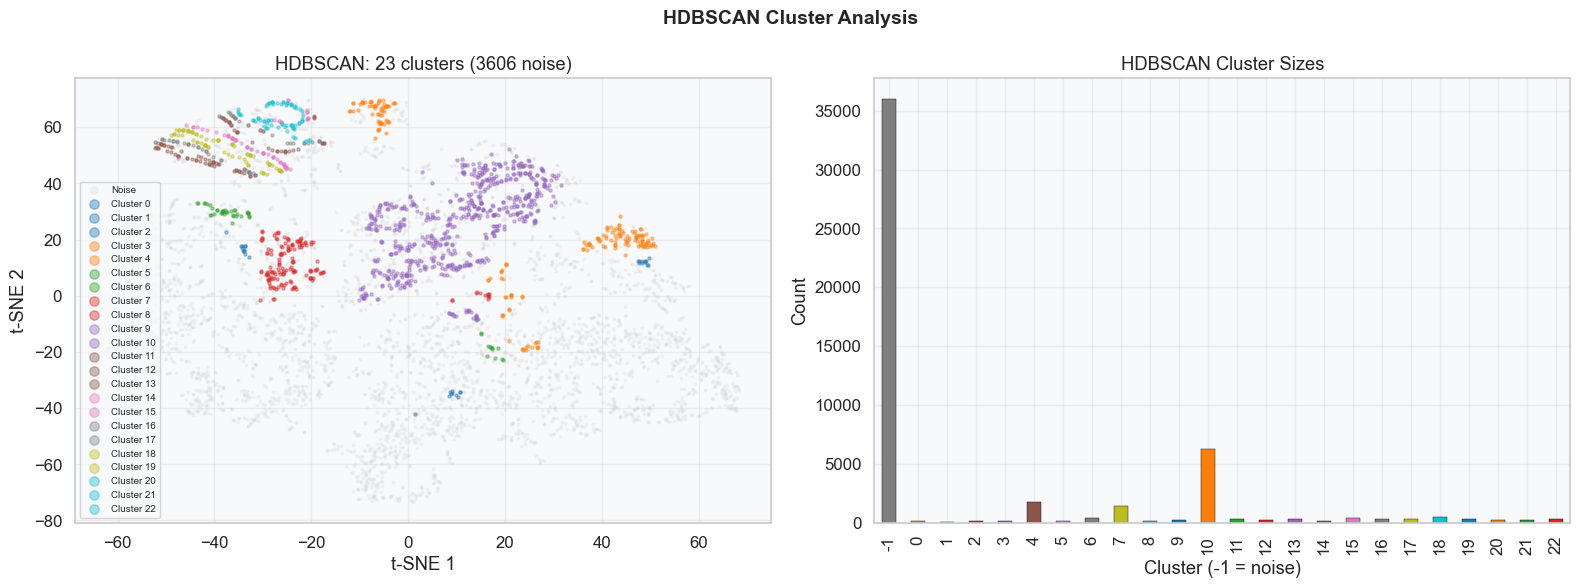

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

valid_hdb = hdb_labels != -1
n_clusters = len(set(hdb_labels)) - 1

if n_clusters > 0 and valid_hdb.sum() > 0:
    from sklearn.manifold import TSNE
    sample_idx = np.random.choice(len(X_scaled), min(5000, len(X_scaled)), replace=False)
    X_sample = X_scaled[sample_idx]
    hdb_sample = hdb_labels[sample_idx]
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X_sample)
    
    noise_mask = hdb_sample == -1
    axes[0].scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
                    c='lightgray', s=3, alpha=0.2, label='Noise')
    
    unique_labels = sorted(set(hdb_sample) - {-1})
    cmap = plt.cm.get_cmap('tab10', len(unique_labels))
    for li, label in enumerate(unique_labels):
        lmask = hdb_sample == label
        axes[0].scatter(X_2d[lmask, 0], X_2d[lmask, 1],
                        c=[cmap(li)], s=5, alpha=0.4, label=f'Cluster {label}')
    
    axes[0].set_title(f'HDBSCAN: {n_clusters} clusters ({noise_mask.sum()} noise)')
    axes[0].legend(fontsize=7, markerscale=3)
    axes[0].set_xlabel('t-SNE 1')
    axes[0].set_ylabel('t-SNE 2')
else:
    axes[0].text(0.5, 0.5, 'No HDBSCAN clusters found', transform=axes[0].transAxes, ha='center')

cluster_sizes = pd.Series(hdb_labels).value_counts().sort_index()
colors_hdb = ['gray' if k == -1 else plt.cm.tab10(i % 10) for i, k in enumerate(cluster_sizes.index)]
cluster_sizes.plot(kind='bar', ax=axes[1], color=colors_hdb, edgecolor='black', linewidth=0.3)
axes[1].set_title('HDBSCAN Cluster Sizes')
axes[1].set_xlabel('Cluster (-1 = noise)')
axes[1].set_ylabel('Count')

plt.suptitle('HDBSCAN Cluster Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
station_stats = {}
nivel_col = 'NIVEL_INST' if 'NIVEL_INST' in df_features.columns else None
if nivel_col:
    for sk in NATURAL_STATIONS:
        s = df_features.loc[df_features['estacao_sk'] == sk, nivel_col].dropna()
        if len(s) < 100:
            continue
        station_stats[sk] = {
            'mean': float(s.mean()), 'std': float(s.std()),
            'p50': float(s.quantile(0.50)), 'p75': float(s.quantile(0.75)),
            'p90': float(s.quantile(0.90)), 'p95': float(s.quantile(0.95)),
            'p99': float(s.quantile(0.99)), 'min': float(s.min()),
            'max': float(s.max())
        }
        p95v = station_stats[sk]['p95']
        p99v = station_stats[sk]['p99']
        print(f'  SK={sk}: P95={p95v:.3f}  P99={p99v:.3f}')
else:
    print('WARNING: NIVEL_INST column not found in df_features')

risk_df = df_features.loc[valid_idx].copy()
risk_df['km_cluster'] = km_labels
risk_df['anomaly_score'] = iso_scores
risk_df['is_anomaly'] = (iso_labels == -1).astype(int)
risk_df['hdb_cluster'] = hdb_labels

def rel(x, ref):
    return (x / ref).clip(0, 1.5) if ref > 1e-8 else pd.Series(0.0, index=x.index)

nivel_rel = pd.Series(0.0, index=risk_df.index)
taxa_rel = pd.Series(0.0, index=risk_df.index)
rmax_rel = pd.Series(0.0, index=risk_df.index)

for sk in NATURAL_STATIONS:
    mask = risk_df['estacao_sk'] == sk
    s = station_stats.get(sk, {})
    if not s or mask.sum() == 0:
        continue
    nivel = risk_df.loc[mask, 'NIVEL_INST'].fillna(0)
    nivel_rel.loc[mask] = rel(nivel, s.get('p99', 1))
    if 'taxa_subida_6h' in risk_df.columns:
        taxa = risk_df.loc[mask, 'taxa_subida_6h'].fillna(0).abs()
        taxa_ref = max(s.get('p95', 1) - s.get('p50', 0), 0.01)
        taxa_rel.loc[mask] = rel(taxa, taxa_ref)
    if 'nivel_rmax_24h' in risk_df.columns:
        rmax_rel.loc[mask] = rel(risk_df.loc[mask, 'nivel_rmax_24h'].fillna(0), s.get('p99', 1))

precip_risk = pd.Series(0.0, index=risk_df.index)
soil_risk = pd.Series(0.0, index=risk_df.index)
if 'precip_accum_24h' in risk_df.columns:
    precip_vals = risk_df['precip_accum_24h'].fillna(0).clip(lower=0)
    precip_p95 = precip_vals.quantile(0.95)
    precip_risk = rel(precip_vals, precip_p95)
if 'soil_saturacao_ratio' in risk_df.columns:
    soil_risk = risk_df['soil_saturacao_ratio'].fillna(0).clip(0, 1)

risk_df['risco_combinado'] = (
    0.40 * nivel_rel +
    0.20 * taxa_rel +
    0.15 * rmax_rel +
    0.15 * precip_risk +
    0.10 * soil_risk
).clip(0, 1)

risk_pcts = risk_df.groupby('estacao_sk')['risco_combinado'].transform(
    lambda x: pd.cut(x,
        bins=[-0.01] + [x.quantile(q) for q in [0.25, 0.50, 0.75, 0.95]] + [1.01],
        labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
)
risk_df['nivel_risco'] = risk_pcts

risk_map = {1: 'Muito Baixo', 2: 'Baixo', 3: 'Moderado', 4: 'Alto', 5: 'Muito Alto'}
risk_df['categoria_risco'] = risk_df['nivel_risco'].map(risk_map)

display(risk_df['categoria_risco'].value_counts())
print('\nRisk thresholds per station:')
for sk in NATURAL_STATIONS:
    mask = risk_df['estacao_sk'] == sk
    s = risk_df.loc[mask, 'risco_combinado']
    if len(s) > 0:
        print(f'  SK={sk}: P50={s.quantile(0.50):.3f}  P75={s.quantile(0.75):.3f}  P95={s.quantile(0.95):.3f}')

  SK=229: P95=2.350  P99=2.830
  SK=232: P95=1.790  P99=2.150
  SK=233: P95=1.080  P99=2.020
  SK=234: P95=2.840  P99=2.920


categoria_risco
Muito Baixo    12931
Moderado       12460
Baixo          12039
Alto            9978
Muito Alto      2496
Name: count, dtype: int64


Risk thresholds per station:
  SK=229: P50=0.278  P75=0.370  P95=0.479
  SK=232: P50=0.320  P75=0.371  P95=0.499
  SK=233: P50=0.035  P75=0.108  P95=0.377
  SK=234: P50=0.484  P75=0.497  P95=0.546


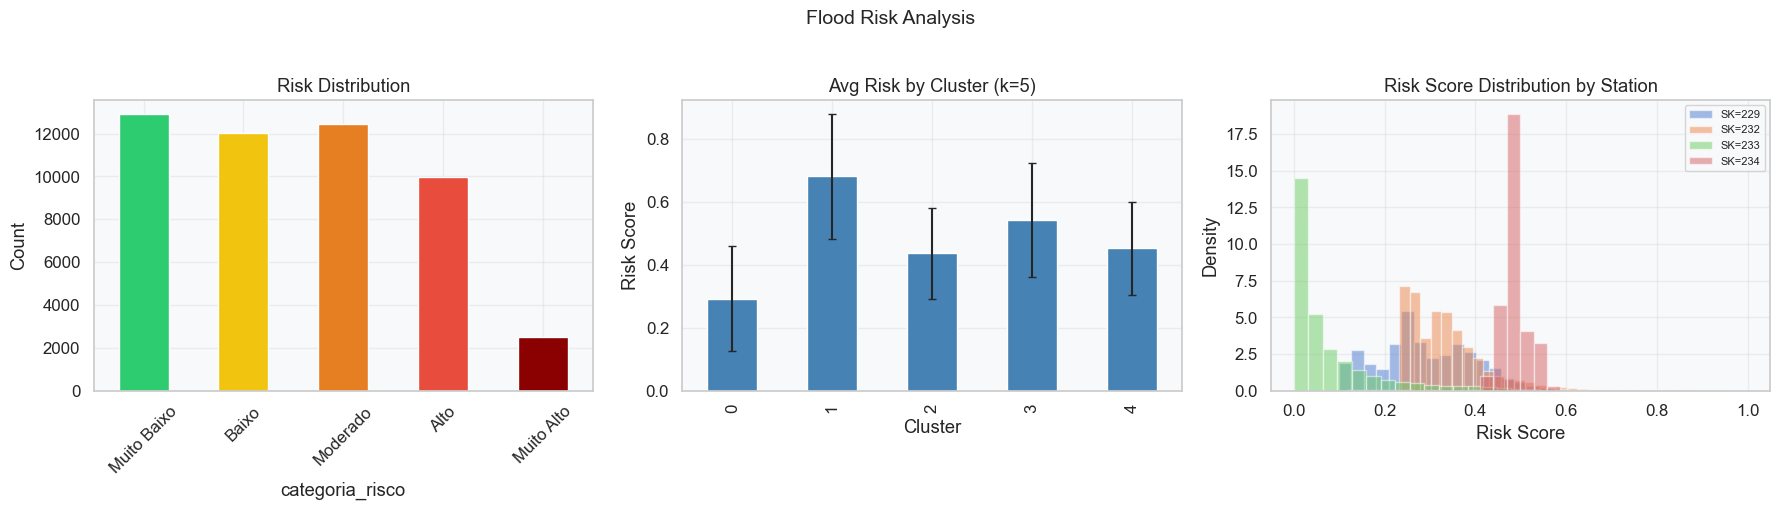

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

risk_counts = risk_df['categoria_risco'].value_counts().reindex(
    ['Muito Baixo', 'Baixo', 'Moderado', 'Alto', 'Muito Alto'], fill_value=0)
colors_risk = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8b0000']
risk_counts.plot(kind='bar', ax=axes[0], color=colors_risk[:len(risk_counts)])
axes[0].set_title('Risk Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

km_risk = risk_df.groupby('km_cluster')['risco_combinado'].agg(['mean', 'std', 'count'])
km_risk['mean'].plot(kind='bar', ax=axes[1], color='steelblue',
                      yerr=km_risk['std'], capsize=3)
axes[1].set_title(f'Avg Risk by Cluster (k={best_k})')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Risk Score')

for sk in NATURAL_STATIONS:
    mask = risk_df['estacao_sk'] == sk
    pct = risk_df.loc[mask, 'risco_combinado']
    axes[2].hist(pct, bins=30, alpha=0.5, label=f'SK={sk}', density=True)
axes[2].set_xlabel('Risk Score')
axes[2].set_ylabel('Density')
axes[2].set_title('Risk Score Distribution by Station')
axes[2].legend(fontsize=8)

plt.suptitle('Flood Risk Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

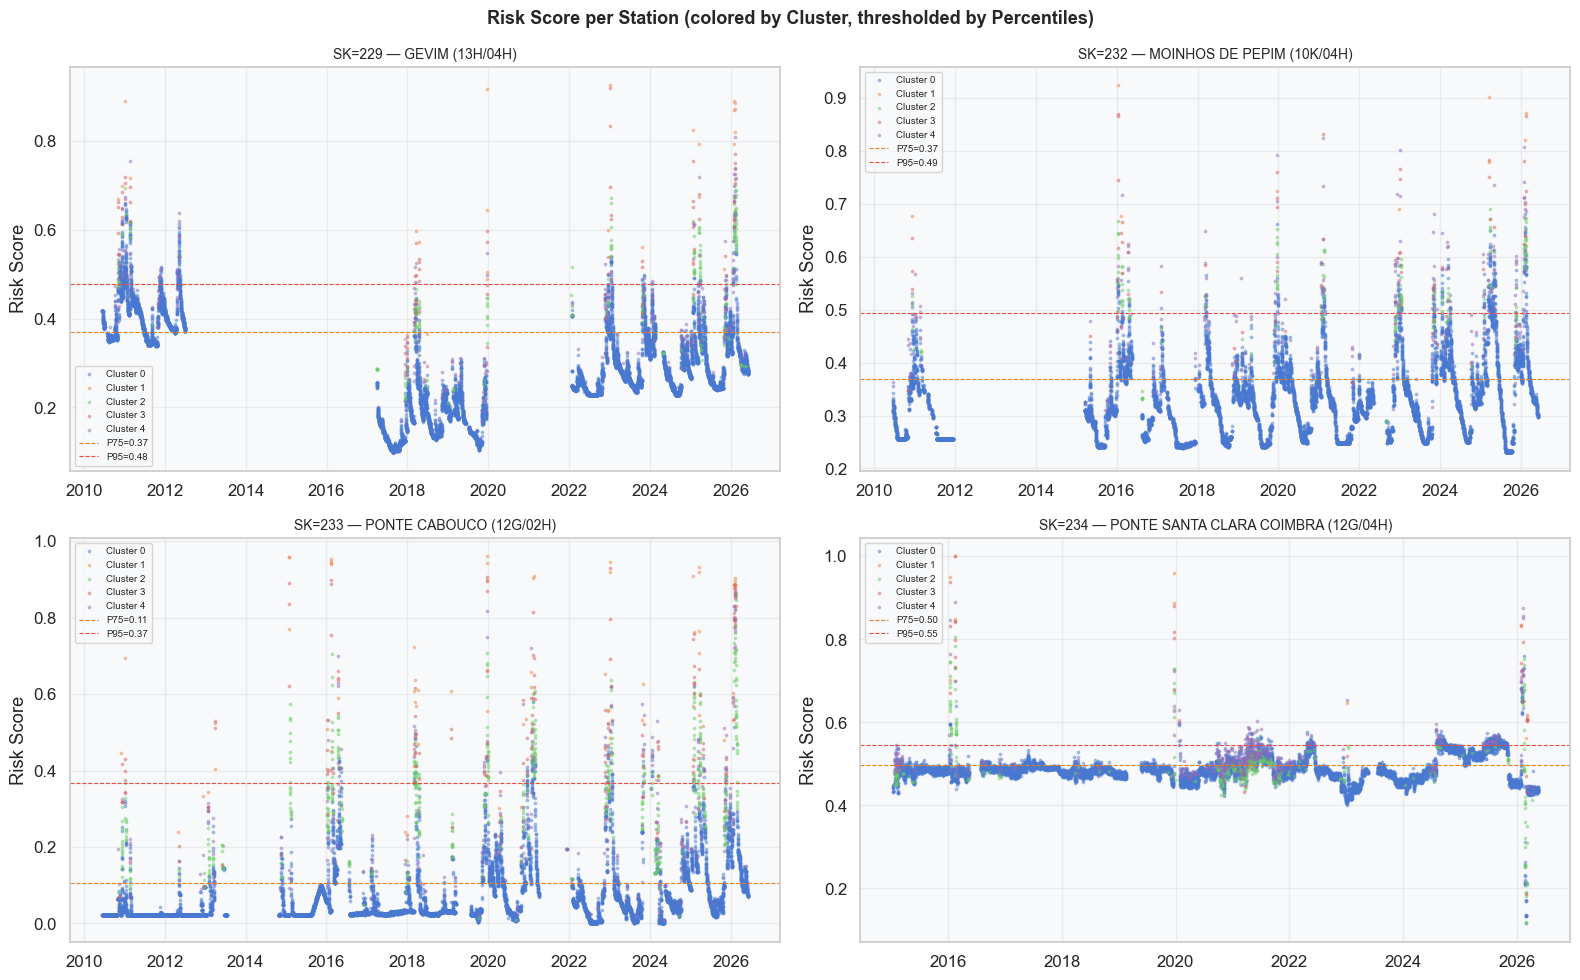

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, sk in enumerate(NATURAL_STATIONS):
    ax = axes[i // 2][i % 2]
    mask = risk_df['estacao_sk'] == sk
    st = risk_df[mask].sort_values('data_hora')
    if len(st) == 0:
        continue

    for cluster in sorted(st['km_cluster'].unique()):
        cmask = st['km_cluster'] == cluster
        ax.scatter(st.loc[cmask, 'data_hora'], st.loc[cmask, 'risco_combinado'],
                   s=3, alpha=0.4, label=f'Cluster {cluster}')

    risk_p50 = st['risco_combinado'].quantile(0.50)
    risk_p75 = st['risco_combinado'].quantile(0.75)
    risk_p95 = st['risco_combinado'].quantile(0.95)
    ax.axhline(risk_p75, color='#e67e22', linestyle='--', linewidth=0.8, label=f'P75={risk_p75:.2f}')
    ax.axhline(risk_p95, color='#e74c3c', linestyle='--', linewidth=0.8, label=f'P95={risk_p95:.2f}')

    name = st['estacao_nome'].iloc[0] if 'estacao_nome' in st.columns else f'SK={sk}'
    ax.set_title(f'SK={sk} — {name}', fontsize=10)
    ax.set_ylabel('Risk Score')
    ax.legend(fontsize=7)

plt.suptitle('Risk Score per Station (colored by Cluster, thresholded by Percentiles)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 5: Forecast Training

LightGBM hybrid global+local models for water level forecasting.

In [23]:
snirh_codes = SNIRH_PARAMS
ph = ','.join(['?'] * len(snirh_codes))
sks = ALL_SNIRH_STATIONS
sk_ph = ','.join(['?'] * len(sks))

snirh_raw = sql_query(conn, """
    SELECT e.estacao_sk, t.data_hora, p.parametro_codigo, f.valor
    FROM gold.fact_medicao f
    JOIN gold.dim_estacao e ON f.estacao_sk = e.estacao_sk
    JOIN gold.dim_parametro p ON f.parametro_sk = p.parametro_sk
    JOIN gold.dim_tempo t ON f.tempo_sk = t.tempo_sk
    WHERE e.sistema_origem = 'SNIRH'
    AND p.parametro_codigo IN (""" + ph + """)
    AND e.estacao_sk IN (""" + sk_ph + """)
""", snirh_codes + sks)

snirh_raw['data_hora'] = pd.to_datetime(snirh_raw['data_hora'])
snirh_raw.dropna(subset=['valor'], inplace=True)

snirh_pivot = snirh_raw.pivot_table(
    index='data_hora', columns=['estacao_sk', 'parametro_codigo'],
    values='valor', aggfunc='first')
snirh_pivot.columns = ['SNIRH_SK{}_{}'.format(c[0], PARAM_ALIAS.get(c[1], c[1]).replace('_DIA', ''))
                        for c in snirh_pivot.columns]
snirh_pivot = snirh_pivot.sort_index()

print(f'SNIRH pivot: {snirh_pivot.shape}')
print(f'Columns: {list(snirh_pivot.columns[:10])}...')

SNIRH pivot: (126304, 20)
Columns: ['SNIRH_SK223_CAUDAL_AFLUENTE', 'SNIRH_SK224_CAUDAL_DESC', 'SNIRH_SK224_CAUDAL_AFLUENTE', 'SNIRH_SK225_CAUDAL_AFLUENTE', 'SNIRH_SK226_CAUDAL_DESC', 'SNIRH_SK226_CAUDAL_AFLUENTE', 'SNIRH_SK228_CAUDAL_DESC', 'SNIRH_SK228_CAUDAL_AFLUENTE', 'SNIRH_SK229_NIVEL_INST', 'SNIRH_SK229_NIVEL_MED']...


In [24]:
prox_map = {}
prox_rows = sql_query(conn, "SELECT source_station_sk, target_station_sk "
                             "FROM ctl.map_spatial_proximity WHERE is_nearest = 1")
for _, r in prox_rows.iterrows():
    prox_map[r['source_station_sk']] = r['target_station_sk']

era5_all = ['tp', 't2m', 'swvl1', 'swvl2', 'swvl3', 'swvl4']
era5_ph = ','.join(['?'] * len(era5_all))
era5_target_sks = [int(prox_map[sk]) for sk in NATURAL_STATIONS if sk in prox_map]
era5_sk_ph = ','.join(['?'] * len(era5_target_sks))

era5_raw = sql_query(conn, """
    SELECT e.estacao_sk, t.data_hora, p.parametro_codigo, f.valor
    FROM gold.fact_medicao f
    JOIN gold.dim_estacao e ON f.estacao_sk = e.estacao_sk
    JOIN gold.dim_parametro p ON f.parametro_sk = p.parametro_sk
    JOIN gold.dim_tempo t ON f.tempo_sk = t.tempo_sk
    WHERE e.sistema_origem = 'ERA5'
    AND p.parametro_codigo IN (""" + era5_ph + """)
    AND e.estacao_sk IN (""" + era5_sk_ph + """)
""", era5_all + era5_target_sks)

era5_raw['data_hora'] = pd.to_datetime(era5_raw['data_hora'])
era5_raw.dropna(subset=['valor'], inplace=True)

era5_pivot = era5_raw.pivot_table(
    index='data_hora', columns=['estacao_sk', 'parametro_codigo'],
    values='valor', aggfunc='first')
era5_pivot.columns = ['ERA5_SK{}_{}'.format(c[0], PARAM_ALIAS.get(c[1], c[1])) for c in era5_pivot.columns]
era5_hourly = era5_pivot.resample('h').mean()
era5_hourly.index = era5_hourly.index + pd.Timedelta(hours=12)

print(f'ERA5 hourly: {era5_hourly.shape}')

ERA5 hourly: (140112, 18)


In [25]:
station_frames = {}
for sk in NATURAL_STATIONS:
    parts = [snirh_pivot.filter(like=f'SNIRH_SK{sk}_')]

    era5_sk = prox_map.get(sk)
    if era5_sk:
        era5_cols = [c for c in era5_hourly.columns if f'SK{era5_sk}_' in c]
        if era5_cols:
            era5_part = era5_hourly[era5_cols].copy()
            era5_part.columns = [c.replace(f'_SK{era5_sk}_', '_') for c in era5_part.columns]
            parts.append(era5_part)

    for other_sk in NATURAL_STATIONS:
        if other_sk == sk:
            continue
        other_cols = [c for c in snirh_pivot.columns if c.startswith(f'SNIRH_SK{other_sk}_NIVEL_INST')]
        if other_cols:
            other_part = snirh_pivot[other_cols].copy()
            other_part.columns = [f'XSK{other_sk}_NIVEL_INST']
            parts.append(other_part)

    merged = pd.concat(parts, axis=1, join='outer').sort_index()
    merged['station_sk'] = sk
    station_frames[sk] = merged

for sk, df in station_frames.items():
    print(f'  SK={sk}: {len(df):,} rows, {len(df.columns)} cols')

  SK=229: 140,257 rows, 12 cols
  SK=232: 140,257 rows, 12 cols
  SK=233: 140,257 rows, 13 cols
  SK=234: 140,257 rows, 12 cols


In [26]:
station_stats = {}
for sk in NATURAL_STATIONS:
    col = f'SNIRH_SK{sk}_NIVEL_INST'
    if col not in station_frames[sk].columns:
        continue
    s = station_frames[sk][col].dropna()
    if len(s) < 100:
        continue
    station_stats[sk] = {
        'mean': float(s.mean()), 'std': float(s.std()),
        'p50': float(s.quantile(0.50)), 'p75': float(s.quantile(0.75)),
        'p90': float(s.quantile(0.90)), 'p95': float(s.quantile(0.95)),
        'p99': float(s.quantile(0.99)), 'min': float(s.min()), 'max': float(s.max()),
    }

stats_df = pd.DataFrame(station_stats).T
display(stats_df.style.set_caption('Station Statistics (NIVEL_INST)'))

,mean,std,p50,p75,p90,p95,p99,min,max
229,1.474034,0.545497,1.410000,1.850000,2.180000,2.360000,2.840000,0.490000,4.810000
232,1.263643,0.279790,1.230000,1.410000,1.610000,1.790000,2.170000,0.910000,3.550000
233,0.284813,0.435163,0.110000,0.330000,0.720000,1.070000,2.080000,-0.250000,5.550000
234,2.531796,0.205128,2.530000,2.590000,2.770000,2.840000,2.920000,0.120000,4.700000


In [27]:
HORIZON = 1

combined = pd.concat(station_frames.values(), axis=0).sort_index()
combined['station_sk'] = combined['station_sk'].astype(int)

target_cols = [f'SNIRH_SK{sk}_NIVEL_INST' for sk in NATURAL_STATIONS]
feature_cols = ['station_sk']
feature_cols += [c for c in combined.columns
                 if c not in target_cols and c != 'station_sk'
                 and not c.startswith('SNIRH_SK')
                 and not c.startswith('XSK')]

for other_sk in NATURAL_STATIONS:
    col = f'XSK{other_sk}_NIVEL_INST'
    if col in combined.columns:
        feature_cols.append(col)

existing_feats = [c for c in feature_cols if c in combined.columns]
combined[existing_feats] = combined[existing_feats].fillna(0)

df_model = combined.copy()
target_col = 'nivel_atual'
for sk in NATURAL_STATIONS:
    nc = f'SNIRH_SK{sk}_NIVEL_INST'
    if nc in df_model.columns:
        mask = df_model['station_sk'] == sk
        df_model.loc[mask, target_col] = df_model.loc[mask, nc]

df_model.dropna(subset=[target_col], inplace=True)
df_model[target_col] = df_model[target_col].astype(float)
df_model['target'] = df_model.groupby('station_sk')[target_col].shift(-HORIZON)
df_model = df_model.dropna(subset=['target'])

X = df_model[existing_feats].copy()
y = df_model['target'].copy()
X['station_sk'] = X['station_sk'].astype(int)

print(f'Model data: {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'Target: NIVEL_INST +{HORIZON}h')

Model data: 375,830 rows x 11 features
Target: NIVEL_INST +1h


In [28]:
LGB_PARAMS = {
    'objective': 'regression', 'metric': ['mae', 'rmse'],
    'num_leaves': 127, 'learning_rate': 0.05,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5,
    'min_child_samples': 30, 'lambda_l1': 0.1, 'lambda_l2': 0.1,
    'seed': 42, 'verbose': -1,
}

tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    dtrain = lgb.Dataset(X_train, label=y_train,
                         categorical_feature=['station_sk'], free_raw_data=False)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain, free_raw_data=False)

    model = lgb.train(LGB_PARAMS, dtrain, num_boost_round=2000,
                      valid_sets=[dval],
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                 lgb.log_evaluation(500)])

    pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)

    fold_metrics.append({'fold': fold + 1, 'mae': mae, 'rmse': rmse, 'r2': r2})
    print(f'  Fold {fold+1}: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}  trees={model.best_iteration}')

folds_df = pd.DataFrame(fold_metrics)
print(f'\nAVG: MAE={folds_df["mae"].mean():.4f}  RMSE={folds_df["rmse"].mean():.4f}  R2={folds_df["r2"].mean():.4f}')

  Fold 1: MAE=0.2562  RMSE=0.4813  R2=0.7550  trees=282
  Fold 2: MAE=0.1816  RMSE=0.3108  R2=0.8711  trees=54
  Fold 3: MAE=0.1571  RMSE=0.2276  R2=0.9331  trees=167
  Fold 4: MAE=0.2061  RMSE=0.2909  R2=0.8752  trees=86
  Fold 5: MAE=0.1953  RMSE=0.2798  R2=0.8940  trees=103

AVG: MAE=0.1993  RMSE=0.3181  R2=0.8657


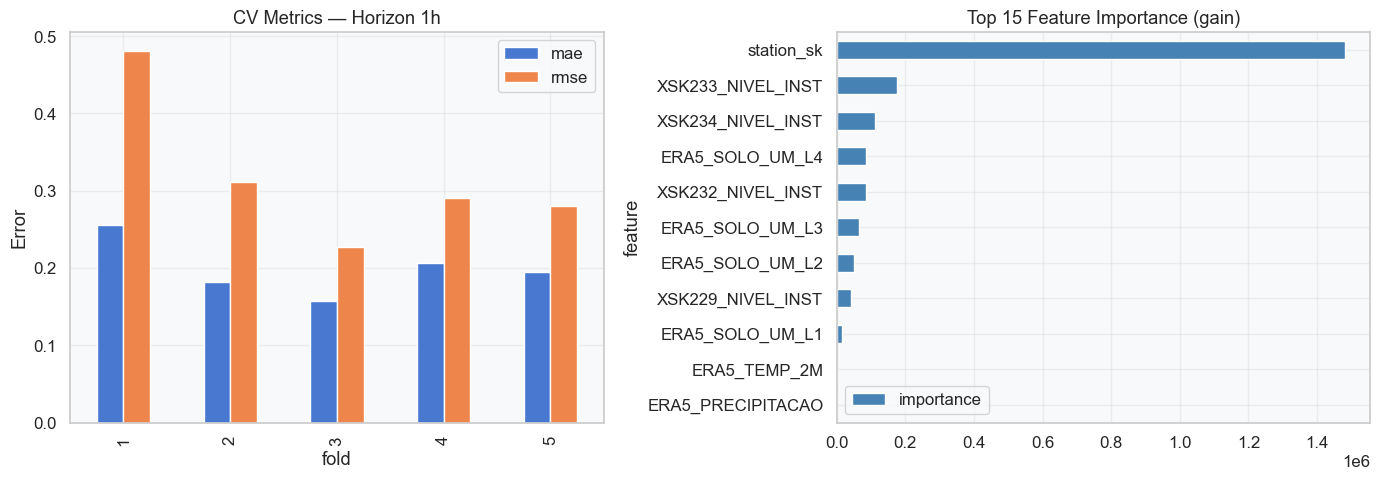

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds_df.plot(x='fold', y=['mae', 'rmse'], kind='bar', ax=axes[0])
axes[0].set_title(f'CV Metrics — Horizon {HORIZON}h')
axes[0].set_ylabel('Error')

imp = model.feature_importance(importance_type='gain')
feat_names = model.feature_name()
imp_df = pd.DataFrame({'feature': feat_names, 'importance': imp}).sort_values('importance', ascending=False).head(15)
imp_df.plot(kind='barh', x='feature', y='importance', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Feature Importance (gain)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

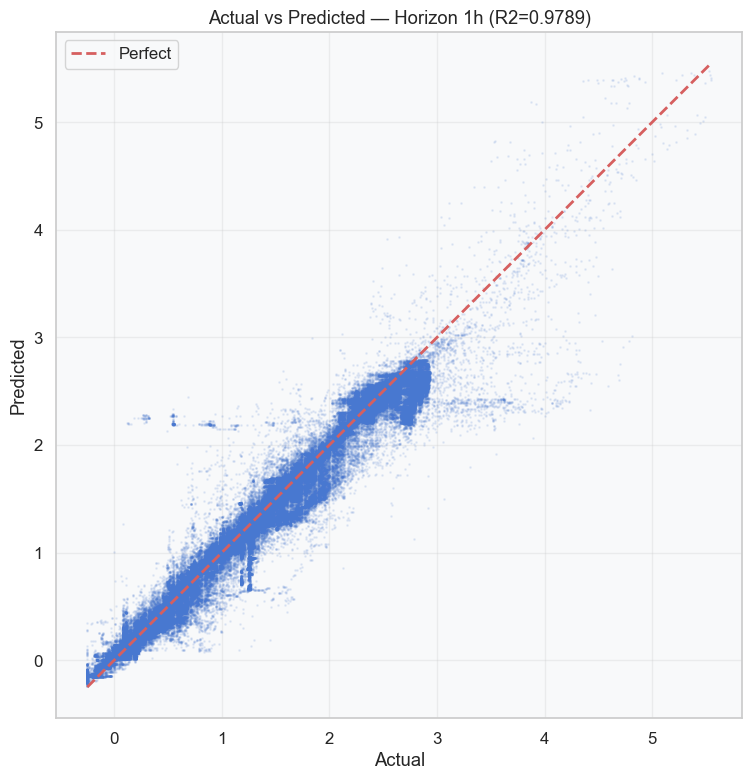

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))

y_pred = model.predict(X)
ax.scatter(y, y_pred, alpha=0.1, s=1)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'Actual vs Predicted — Horizon {HORIZON}h (R2={r2_score(y, y_pred):.4f})')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## Section 6: Predict Now

Load trained models and run real-time predictions for each station.

In [31]:
feature_list_path = os.path.join(MODELS_DIR, 'features', 'feature_list.pkl')
stats_path = os.path.join(MODELS_DIR, 'features', 'station_stats.pkl')

if not os.path.exists(feature_list_path):
    print('ERROR: No trained models found. Run Section 5 first or run forecast_ml.py')
else:
    with open(feature_list_path, 'rb') as f:
        feature_list = pickle.load(f)
    with open(stats_path, 'rb') as f:
        station_stats_trained = pickle.load(f)
    print(f'Loaded feature list: {len(feature_list)} features')
    print(f'Loaded stats for stations: {list(station_stats_trained.keys())}')

Loaded feature list: 138 features
Loaded stats for stations: [229, 232, 233, 234]


In [32]:
recent_snirh = sql_query(conn, """
    SELECT e.estacao_sk, t.data_hora, p.parametro_codigo, f.valor
    FROM gold.fact_medicao f
    JOIN gold.dim_estacao e ON f.estacao_sk = e.estacao_sk
    JOIN gold.dim_parametro p ON f.parametro_sk = p.parametro_sk
    JOIN gold.dim_tempo t ON f.tempo_sk = t.tempo_sk
    WHERE e.estacao_sk IN (""" + ','.join(['?'] * len(ALL_SNIRH_STATIONS)) + """)
    AND p.parametro_codigo IN (""" + ','.join(['?'] * len(SNIRH_PARAMS)) + """)
    AND t.data_hora >= DATEADD(HOUR, -400, GETDATE())
    ORDER BY t.data_hora
""", ALL_SNIRH_STATIONS + SNIRH_PARAMS)

recent_snirh['data_hora'] = pd.to_datetime(recent_snirh['data_hora'])
recent_snirh.dropna(subset=['valor'], inplace=True)

snirh_recent_pivot = recent_snirh.pivot_table(
    index='data_hora', columns=['estacao_sk', 'parametro_codigo'],
    values='valor', aggfunc='first')
snirh_recent_pivot.columns = ['SK{}_{}'.format(c[0], PARAM_ALIAS.get(c[1], c[1]).replace('_DIA', ''))
                              for c in snirh_recent_pivot.columns]
snirh_recent_pivot = snirh_recent_pivot.sort_index()

print(f'Recent SNIRH: {len(snirh_recent_pivot)} hours')

Recent SNIRH: 359 hours


In [33]:
predictions = []

for sk in NATURAL_STATIONS:
    nivel_col = f'SK{sk}_NIVEL_INST'
    if nivel_col not in snirh_recent_pivot.columns:
        print(f'  SK={sk}: no recent data, skipping')
        continue

    nivel = snirh_recent_pivot[nivel_col].dropna()
    if len(nivel) < 10:
        print(f'  SK={sk}: insufficient data ({len(nivel)} pts)')
        continue

    latest_ts = nivel.index[-1]
    latest_nivel = float(nivel.iloc[-1])
    stats = station_stats_trained.get(sk, {})

    feats = {'station_sk': sk}
    for lag in [1, 3, 6, 12, 24, 48, 72, 168, 336]:
        target_ts = latest_ts - pd.Timedelta(hours=lag)
        if target_ts in nivel.index:
            feats[f'nivel_lag_{lag}h'] = float(nivel.loc[target_ts])
        else:
            mask = nivel.index <= target_ts
            feats[f'nivel_lag_{lag}h'] = float(nivel[mask].iloc[-1]) if mask.any() else 0

    for delta in [1, 3, 6, 12, 24]:
        feats[f'nivel_delta_{delta}h'] = latest_nivel - feats.get(f'nivel_lag_{delta}h', latest_nivel)

    for w in [3, 6, 12, 24]:
        window = nivel.loc[nivel.index >= latest_ts - pd.Timedelta(hours=w)]
        if len(window) > 0:
            feats[f'nivel_rmean_{w}h'] = float(window.mean())
            feats[f'nivel_rmax_{w}h'] = float(window.max())
            feats[f'nivel_rstd_{w}h'] = float(window.std()) if len(window) > 1 else 0

    feats['hour_sin'] = np.sin(2 * np.pi * latest_ts.hour / 24)
    feats['hour_cos'] = np.cos(2 * np.pi * latest_ts.hour / 24)
    feats['month_sin'] = np.sin(2 * np.pi * latest_ts.month / 12)
    feats['month_cos'] = np.cos(2 * np.pi * latest_ts.month / 12)

    row = pd.DataFrame({k: [v] for k, v in feats.items()})
    for col in feature_list:
        if col not in row.columns:
            row[col] = 0
    row = row[feature_list].fillna(0).replace([np.inf, -np.inf], 0)

    station_preds = {}
    for horizon in FORECAST_HORIZONS:
        gpath = os.path.join(MODELS_DIR, 'models', f'global_NIVEL_INST_h{horizon}.lgb')
        lpath = os.path.join(MODELS_DIR, 'models', f'local_SK{sk}_NIVEL_INST_h{horizon}.lgb')
        if not os.path.exists(gpath):
            continue
        g_model = lgb.Booster(model_file=gpath)
        pred_g = float(g_model.predict(row)[0])
        pred_l = 0
        if os.path.exists(lpath):
            l_model = lgb.Booster(model_file=lpath)
            pred_l = float(l_model.predict(row)[0])
        pred_final = max(pred_g + pred_l, stats.get('min', 0))
        station_preds[horizon] = pred_final

    predictions.append({
        'estacao_sk': sk, 'latest_nivel': latest_nivel, 'latest_ts': latest_ts,
        **{f'pred_{h}h': station_preds.get(h) for h in FORECAST_HORIZONS},
    })
    print(f'  SK={sk}: nivel={latest_nivel:.3f}m  ' +
          '  '.join(f'h{h}={station_preds.get(h, 0):.3f}' for h in FORECAST_HORIZONS))

pred_df = pd.DataFrame(predictions)
display(pred_df)

  SK=229: nivel=1.400m  h1=1.295  h3=1.241  h6=1.282  h12=1.285  h24=1.251
  SK=232: nivel=1.160m  h1=1.063  h3=1.013  h6=1.097  h12=1.121  h24=1.076
  SK=233: nivel=0.240m  h1=0.185  h3=0.202  h6=0.198  h12=0.167  h24=0.181
  SK=234: no recent data, skipping


,estacao_sk,latest_nivel,latest_ts,pred_1h,pred_3h,pred_6h,pred_12h,pred_24h
0,229,1.40,2026-06-05 22:00:00,1.294783,1.241045,1.281944,1.285259,1.251236
1,232,1.16,2026-06-05 22:00:00,1.062959,1.012796,1.096709,1.121313,1.075506
2,233,0.24,2026-06-05 22:00:00,0.184982,0.201764,0.198259,0.166854,0.181238


---
## Section 7: Visualization Suite

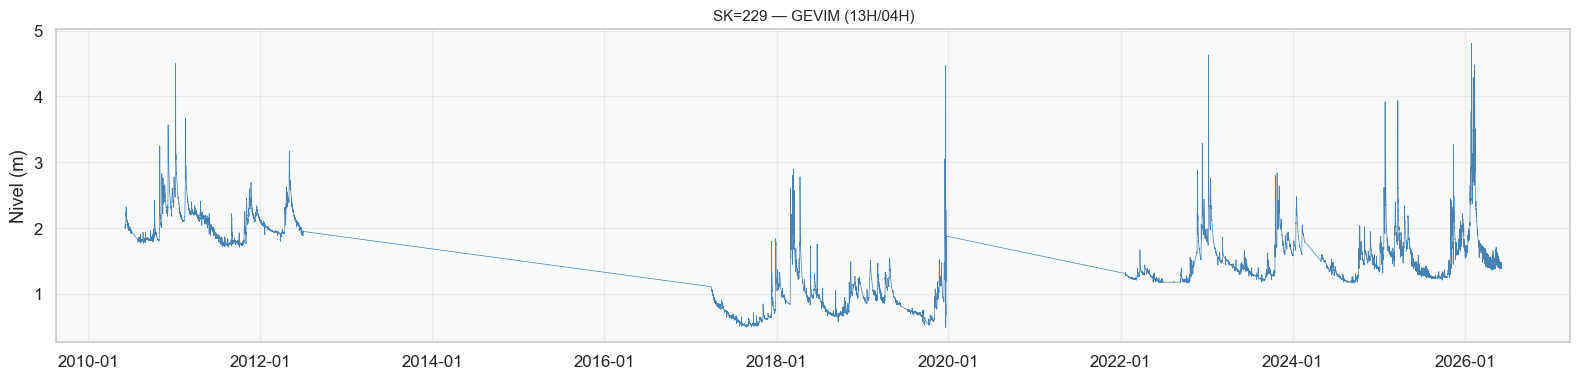

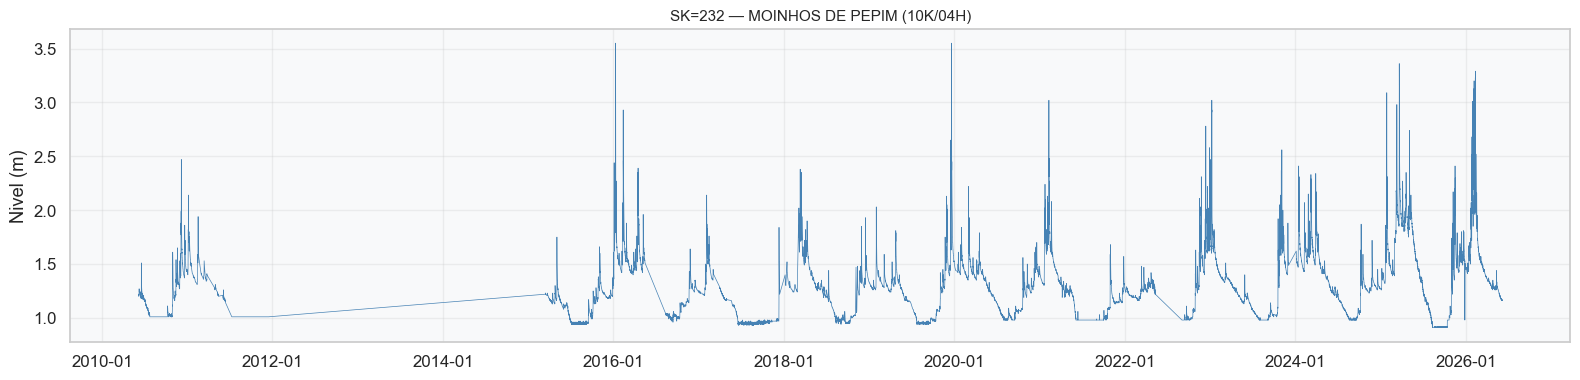

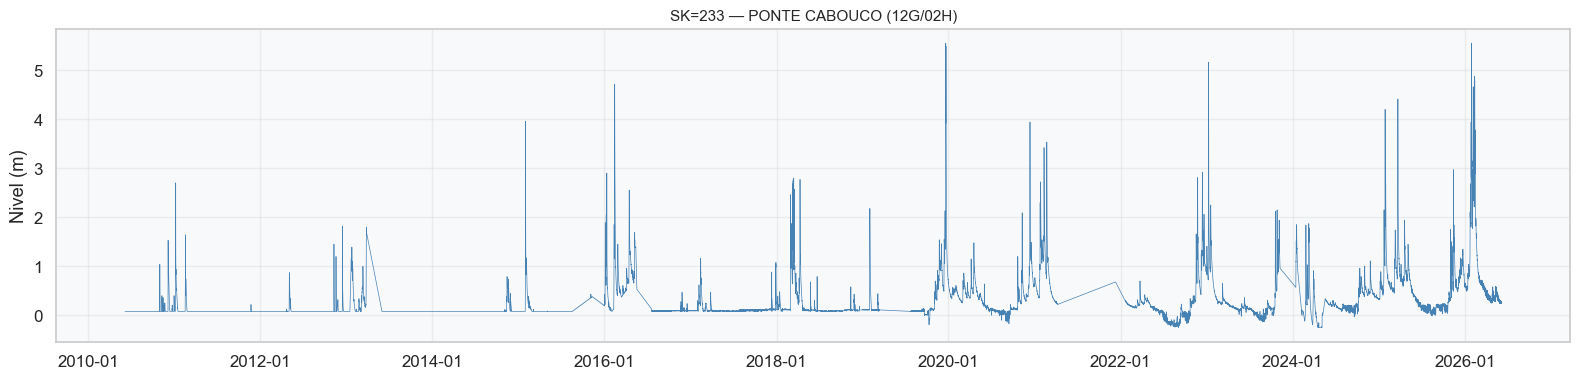

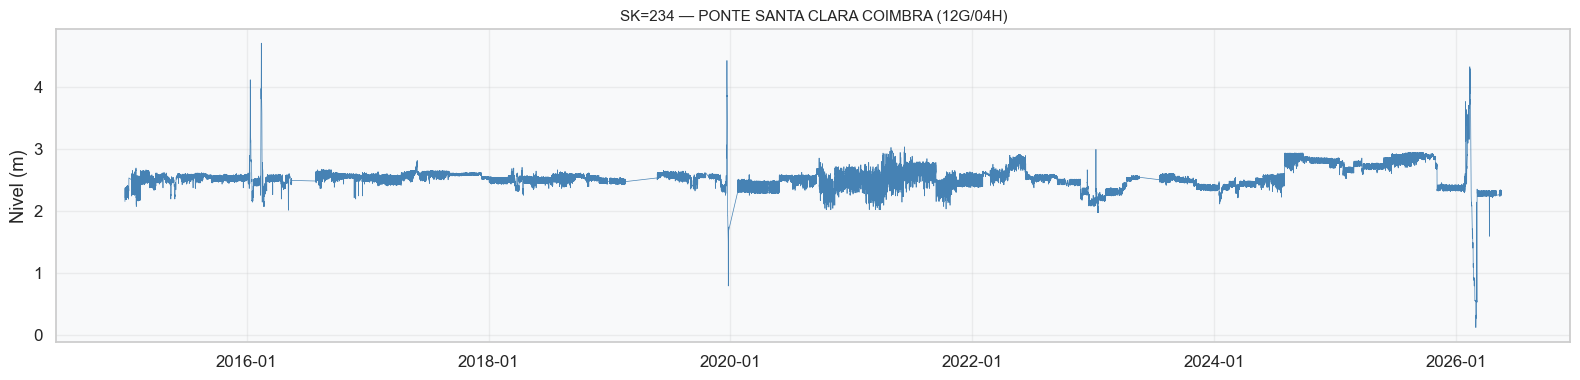

In [34]:
for sk in NATURAL_STATIONS:
    fig, ax = plt.subplots(figsize=(16, 4))
    mask = raw['estacao_sk'] == sk
    st_data = raw[mask].sort_values('data_hora')

    if 'NIVEL_INST' not in st_data.columns:
        nivel_data = st_data[st_data['parametro_codigo'] == '1843']
    else:
        nivel_data = st_data

    if 'NIVEL_INST' not in st_data.columns and len(nivel_data) > 0:
        ax.plot(nivel_data['data_hora'], nivel_data['valor'], linewidth=0.5, color='steelblue')
        ax.set_ylabel('Nivel (m)')
    elif 'NIVEL_INST' in st_data.columns:
        ax.plot(st_data['data_hora'], st_data['NIVEL_INST'], linewidth=0.5, color='steelblue')
        ax.set_ylabel('Nivel (m)')

    name = st_data['estacao_nome'].iloc[0] if len(st_data) > 0 else f'SK={sk}'
    ax.set_title(f'SK={sk} — {name}', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tight_layout()
    plt.show()

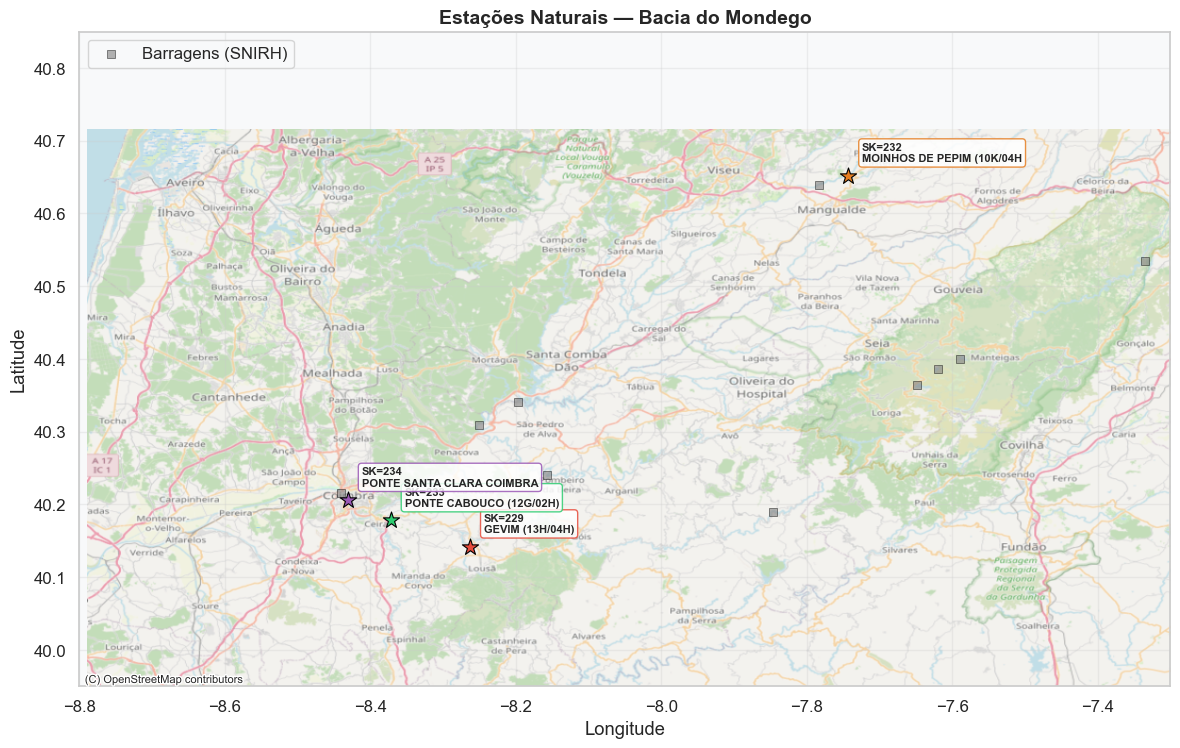

In [44]:
fig, ax = plt.subplots(figsize=(12, 10))

river_lats = [40.63, 40.55, 40.45, 40.38, 40.30, 40.22, 40.20, 40.21, 40.20, 40.18, 40.15, 40.14, 40.10, 40.08, 40.10, 40.13, 40.15, 40.18, 40.20]
river_lons = [7.00, 7.15, 7.30, 7.50, 7.65, 7.90, 8.10, 8.30, 8.43, 8.60, 8.85, 9.00, 9.30, 9.60, 9.90, 10.20, 10.50, 10.80, 11.00]

dam_st = stations[(stations['sistema_origem'] == 'SNIRH') & (~stations['estacao_sk'].isin(NATURAL_STATIONS))]
ax.scatter(dam_st['longitude'], dam_st['latitude'],
           c='gray', s=40, marker='s', alpha=0.6, label='Barragens (SNIRH)', zorder=3, edgecolors='black', linewidth=0.5)

colors_nat = {229: '#e74c3c', 232: '#e67e22', 233: '#2ecc71', 234: '#9b59b6'}
for sk in NATURAL_STATIONS:
    row = stations[stations['estacao_sk'] == sk].iloc[0]
    ax.scatter(row['longitude'], row['latitude'],
               c=colors_nat[sk], s=150, marker='*', zorder=5, edgecolors='black', linewidth=0.8)
    ax.annotate(f"SK={sk}\n{row['estacao_nome'][:25]}",
                (row['longitude'], row['latitude']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor=colors_nat[sk]))

ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, zoom=10, alpha=0.7)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Estações Naturais — Bacia do Mondego', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_xlim(-8.8, -7.3)
ax.set_ylim(39.95, 40.85)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

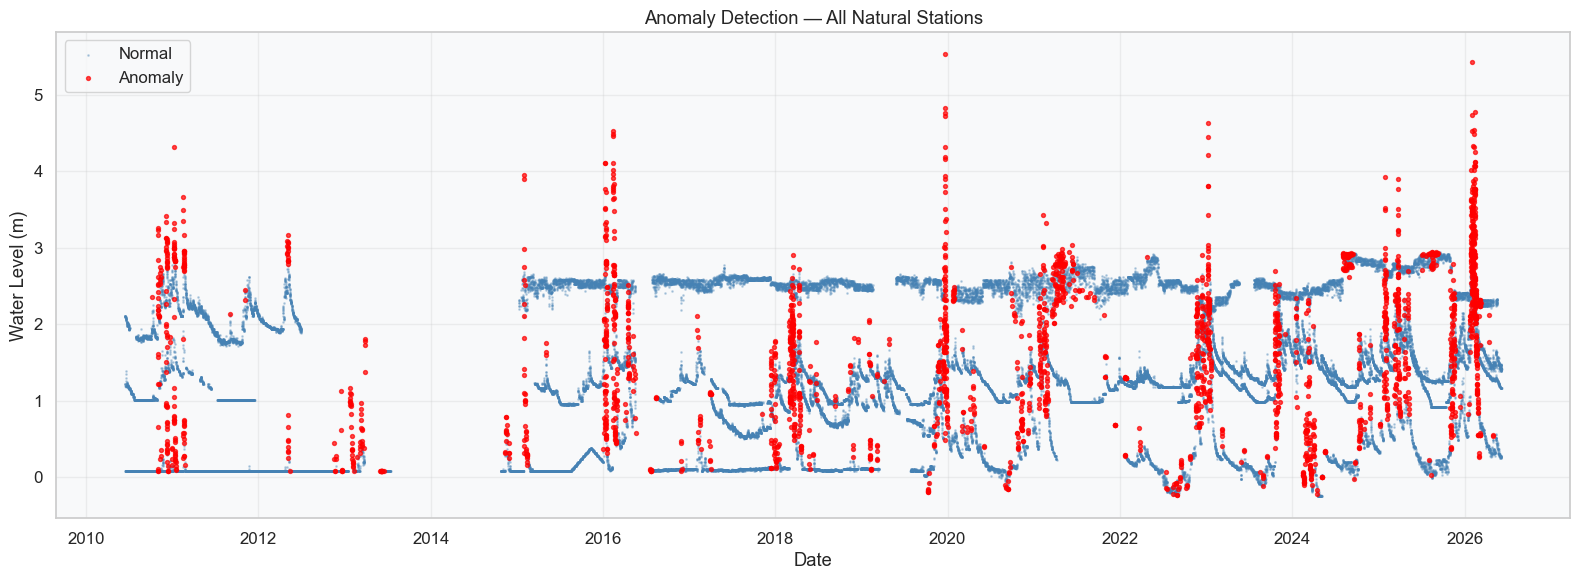

In [36]:
if 'is_anomaly' in risk_df.columns:
    fig, ax = plt.subplots(figsize=(16, 6))

    normal = risk_df[risk_df['is_anomaly'] == 0]
    anomaly = risk_df[risk_df['is_anomaly'] == 1]

    ax.scatter(normal['data_hora'], normal['NIVEL_INST'],
               c='steelblue', s=1, alpha=0.3, label='Normal')
    ax.scatter(anomaly['data_hora'], anomaly['NIVEL_INST'],
               c='red', s=8, alpha=0.7, label='Anomaly')

    ax.set_xlabel('Date')
    ax.set_ylabel('Water Level (m)')
    ax.set_title('Anomaly Detection — All Natural Stations')
    ax.legend()
    plt.tight_layout()
    plt.show()

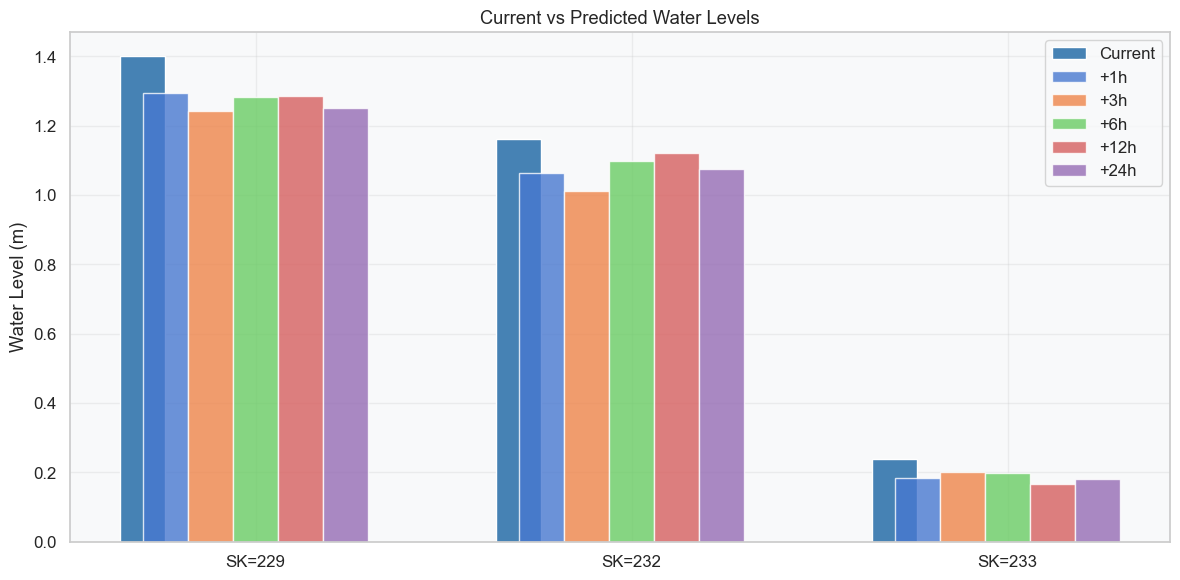

In [37]:
if len(pred_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    x_labels = [f'SK={row.estacao_sk}' for _, row in pred_df.iterrows()]
    x = np.arange(len(pred_df))
    width = 0.12

    ax.bar(x - 2.5 * width, pred_df['latest_nivel'], width, label='Current', color='steelblue')
    for i, h in enumerate(FORECAST_HORIZONS):
        col = f'pred_{h}h'
        if col in pred_df.columns:
            ax.bar(x + (i - 2) * width, pred_df[col], width,
                   label=f'+{h}h', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel('Water Level (m)')
    ax.set_title('Current vs Predicted Water Levels')
    ax.legend()
    plt.tight_layout()
    plt.show()

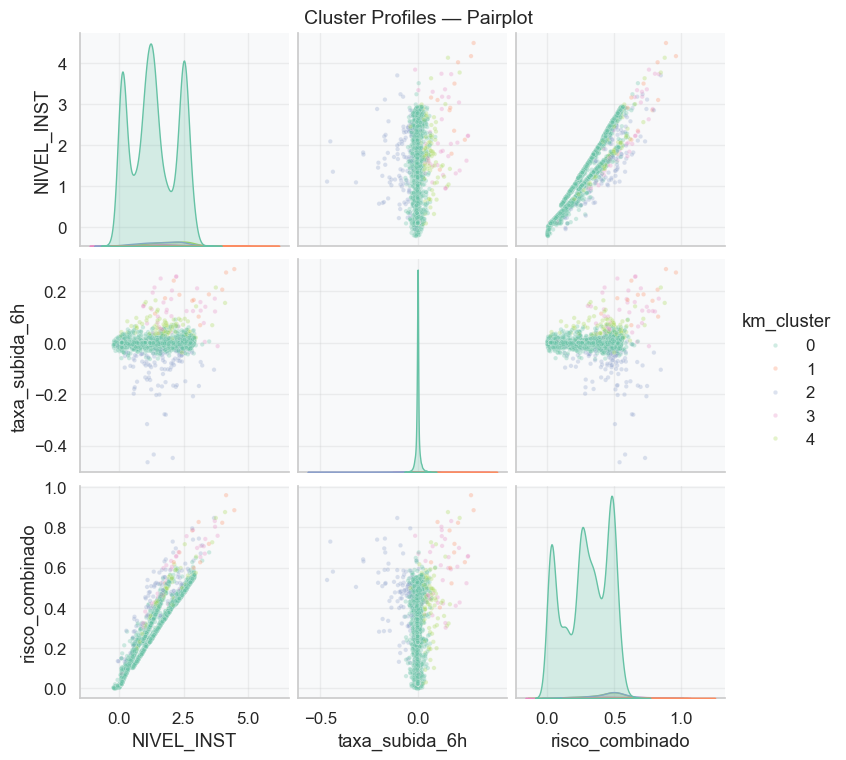

In [38]:
if 'km_cluster' in risk_df.columns:
    numeric_feats = [c for c in ['NIVEL_INST', 'precip_accum_24h', 'soil_saturacao_ratio',
                                  'taxa_subida_6h', 'risco_combinado']
                    if c in risk_df.columns]

    if len(numeric_feats) >= 2:
        sample = risk_df.sample(min(5000, len(risk_df)), random_state=42)
        g = sns.pairplot(sample, vars=numeric_feats, hue='km_cluster',
                         palette='Set2', plot_kws={'alpha': 0.3, 's': 10},
                         diag_kind='kde')
        g.figure.suptitle('Cluster Profiles — Pairplot', y=1.01, fontsize=14)
        plt.show()

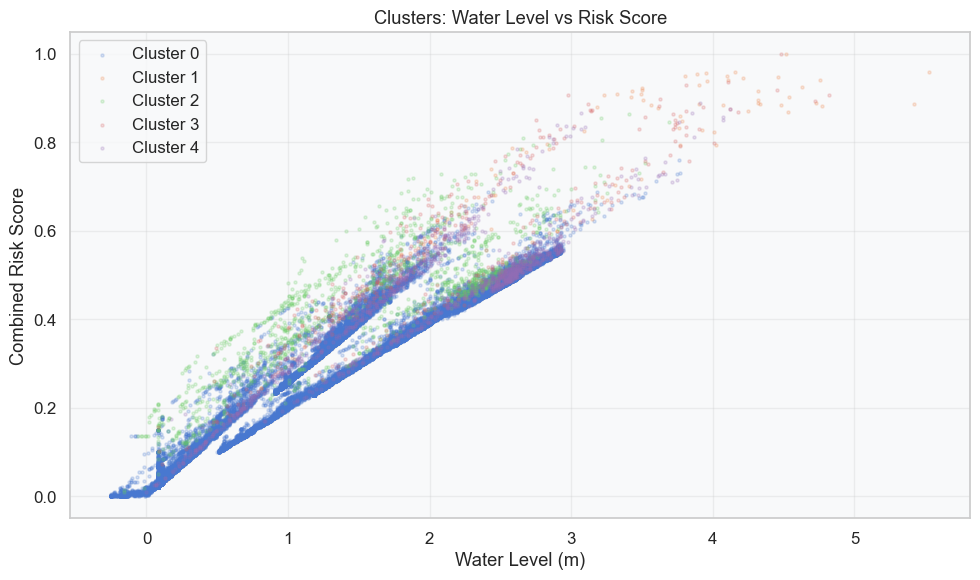

In [39]:
if 'km_cluster' in risk_df.columns and 'NIVEL_INST' in risk_df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))

    for cluster in sorted(risk_df['km_cluster'].unique()):
        mask = risk_df['km_cluster'] == cluster
        ax.scatter(risk_df.loc[mask, 'NIVEL_INST'],
                   risk_df.loc[mask, 'risco_combinado'],
                   alpha=0.2, s=5, label=f'Cluster {cluster}')

    ax.set_xlabel('Water Level (m)')
    ax.set_ylabel('Combined Risk Score')
    ax.set_title('Clusters: Water Level vs Risk Score')
    ax.legend()
    plt.tight_layout()
    plt.show()

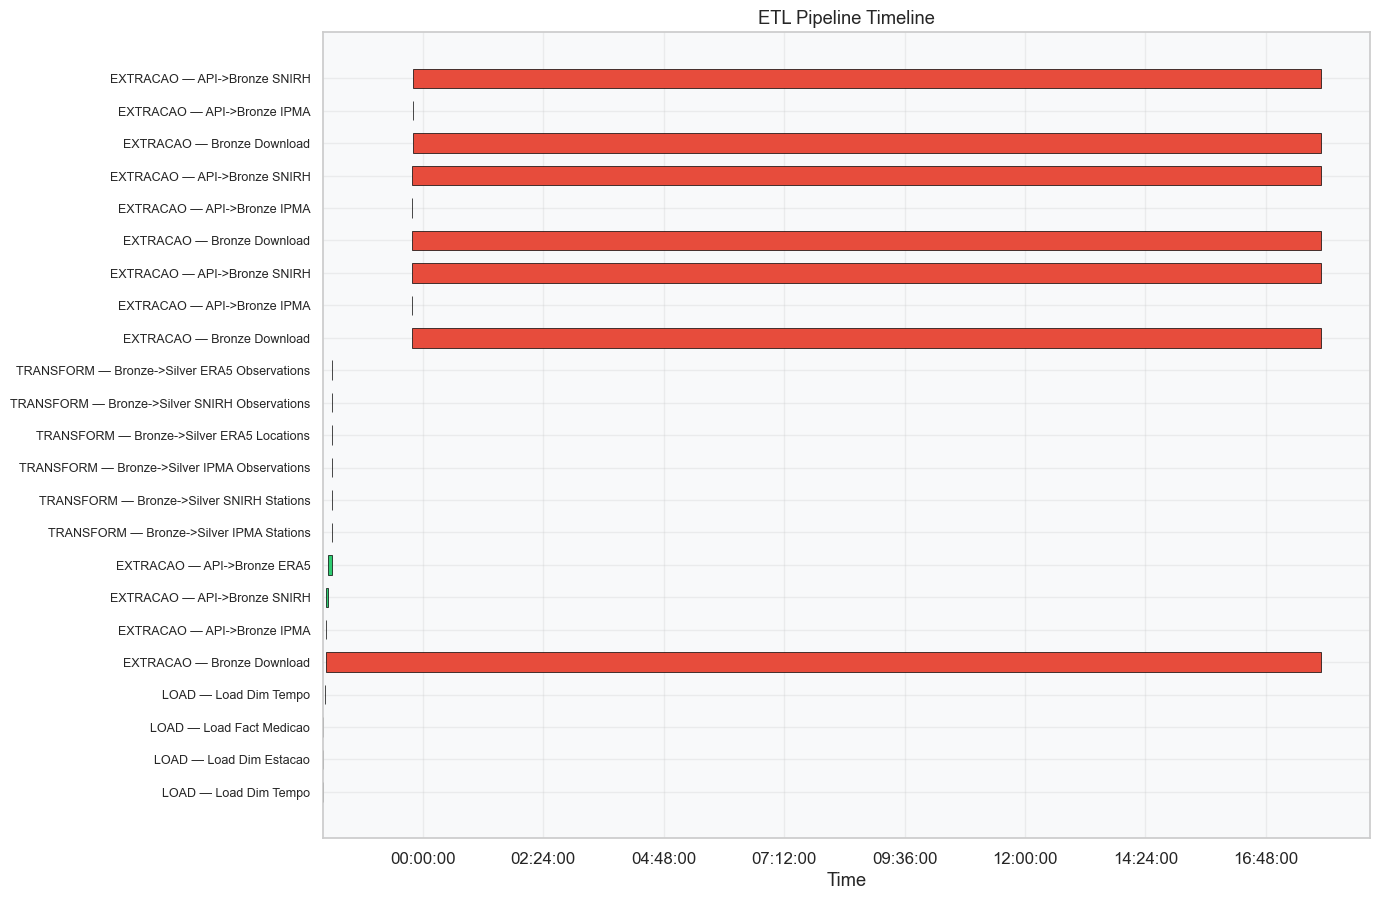

In [40]:
etl = sql_query(conn, """
    SELECT Fase, Passo, Status, Registros_Lidos, Registros_Escritos, Registros_Rejeitados,
           Dt_Inicio, ISNULL(Dt_Fim, GETDATE()) as Dt_Fim,
           DATEDIFF(SECOND, Dt_Inicio, ISNULL(Dt_Fim, GETDATE())) as Duracao_Seg
    FROM logs.ETL_Log
    ORDER BY Dt_Inicio
""")

if len(etl) > 0:
    fig, ax = plt.subplots(figsize=(14, max(4, len(etl) * 0.4)))

    etl['label'] = etl['Fase'] + ' — ' + etl['Passo']
    colors = ['#2ecc71' if s == 'OK' else '#e74c3c' for s in etl['Status']]

    for i, (_, row) in enumerate(etl.iterrows()):
        start = mdates.date2num(row['Dt_Inicio'])
        end = mdates.date2num(row['Dt_Fim'])
        ax.barh(i, end - start, left=start, height=0.6, color=colors[i], edgecolor='black', linewidth=0.5)

    ax.set_yticks(range(len(etl)))
    ax.set_yticklabels(etl['label'], fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.set_title('ETL Pipeline Timeline')
    ax.set_xlabel('Time')
    plt.tight_layout()
    plt.show()

In [41]:
print('Analysis complete —', datetime.now().strftime('%Y-%m-%d %H:%M'))

Analysis complete — 2026-06-07 17:53


---
## Section 8: Flood Labeling (v6)

Binary flood labels from P95 threshold per station. Labels stored in `ml.flood_labels`, thresholds in `ctl.flood_thresholds`.

In [42]:
labels = sql_query(conn, """
    SELECT estacao_sk, data_hora, nivel, nivel_p95,
           flood_6h, flood_12h, flood_24h
    FROM ml.flood_labels
    ORDER BY data_hora
""")

if len(labels) > 0:
    labels['data_hora'] = pd.to_datetime(labels['data_hora'])
    print(f'Flood labels: {len(labels):,} rows')
    for h in [6, 12, 24]:
        col = f'flood_{h}h'
        if col in labels.columns:
            print(f'  h={h}: flood rate {labels[col].mean()*100:.1f}%')
    print(f'Stations: {sorted(labels["estacao_sk"].unique())}')
    display(labels.groupby('estacao_sk').agg(
        total=('flood_6h', 'count'),
        floods_6h=('flood_6h', 'sum'),
        floods_12h=('flood_12h', 'sum'),
        floods_24h=('flood_24h', 'sum'),
        p95=('nivel_p95', 'first')
    ))
else:
    print('No flood labels found. Run flood_labeling.py first.')

Flood labels: 375,834 rows
  h=6: flood rate 5.9%
  h=12: flood rate 6.6%
  h=24: flood rate 7.5%
Stations: [np.int64(229), np.int64(232), np.int64(233), np.int64(234)]


,total,floods_6h,floods_12h,floods_24h,p95
estacao_sk,,,,,
229,75194,3961,4237,4757,2.36
232,98454,5349,5929,6896,1.79
233,111002,5926,6372,7158,1.07
234,91184,6950,8190,9273,2.84


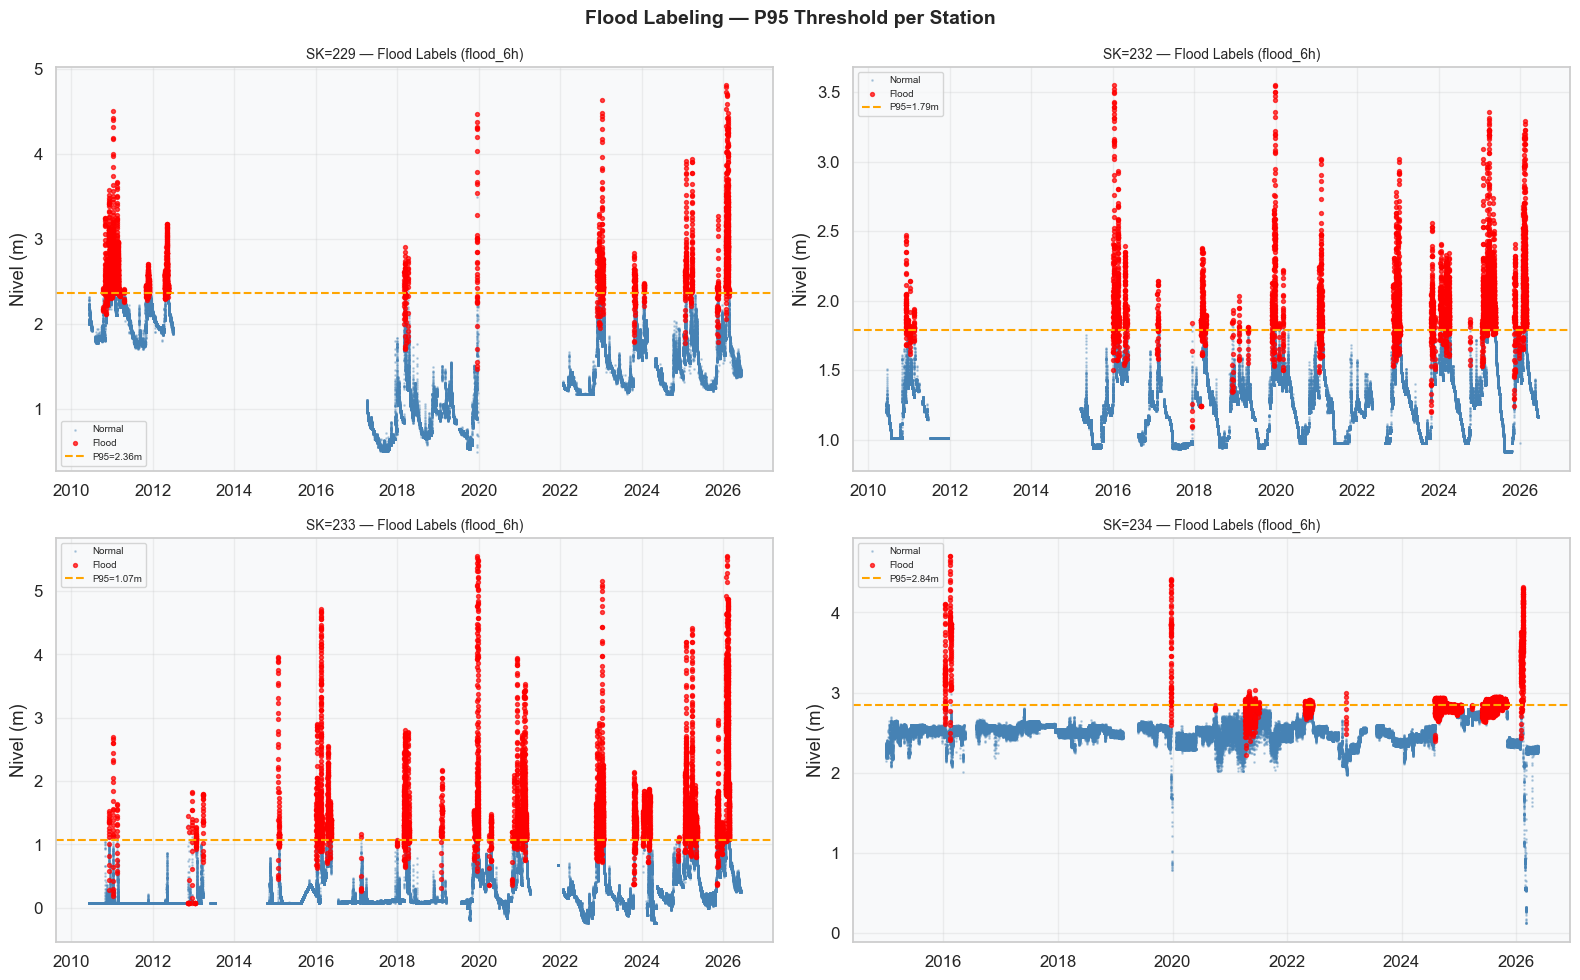

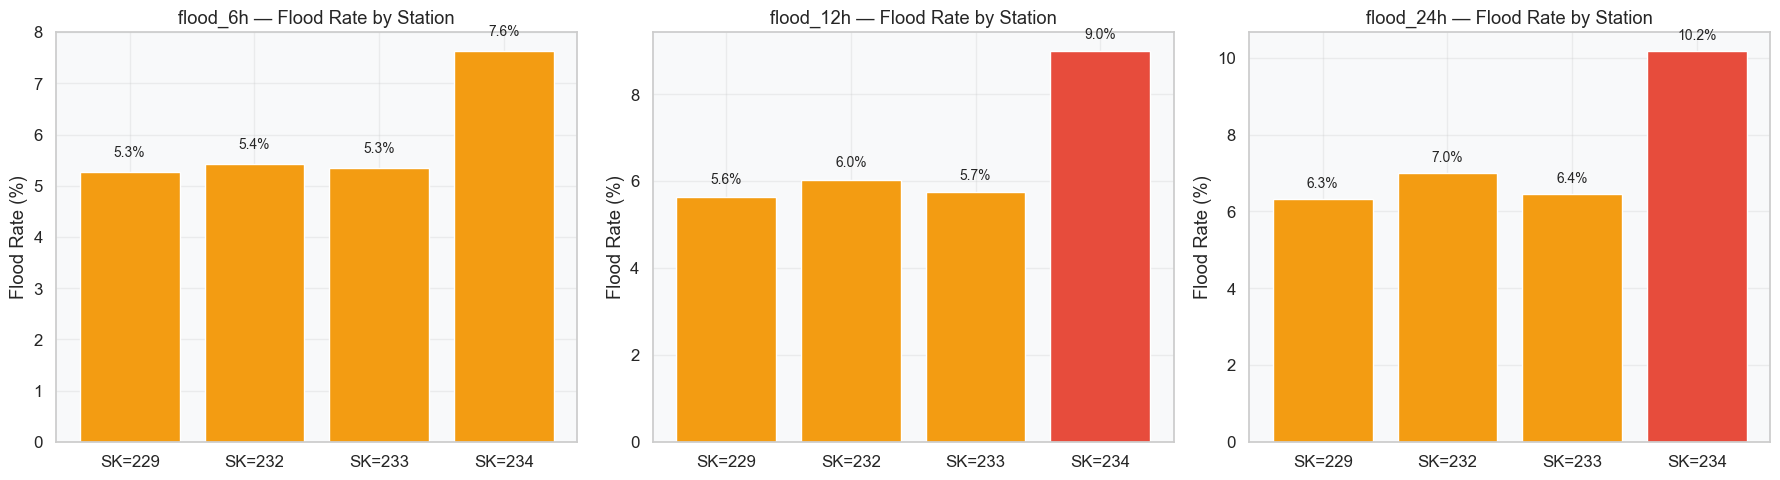

In [45]:
if len(labels) > 0:
    flood_col = 'flood_6h'
    labels['is_flood'] = (labels[flood_col] == 1).astype(int)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    for i, sk in enumerate(sorted(labels['estacao_sk'].unique())):
        ax = axes[i // 2][i % 2]
        st = labels[labels['estacao_sk'] == sk].sort_values('data_hora')
        normal = st[st['is_flood'] == 0]
        flood = st[st['is_flood'] == 1]
        ax.scatter(normal['data_hora'], normal['nivel'], s=1, alpha=0.3, c='steelblue', label='Normal')
        ax.scatter(flood['data_hora'], flood['nivel'], s=8, alpha=0.7, c='red', label='Flood')
        p95v = st['nivel_p95'].iloc[0]
        ax.axhline(p95v, color='orange', linestyle='--', linewidth=1.5, label=f'P95={p95v:.2f}m')
        ax.set_title(f'SK={sk} — Flood Labels ({flood_col})', fontsize=10)
        ax.set_ylabel('Nivel (m)')
        ax.legend(fontsize=7)

    plt.suptitle('Flood Labeling — P95 Threshold per Station', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for j, col in enumerate(['flood_6h', 'flood_12h', 'flood_24h']):
        flood_counts = labels.groupby('estacao_sk')[col].agg(['sum', 'count'])
        flood_counts['rate'] = flood_counts['sum'] / flood_counts['count'] * 100
        x = range(len(flood_counts))
        axes[j].bar(x, flood_counts['rate'],
                    color=['#e74c3c' if r > 8 else '#f39c12' if r > 5 else '#2ecc71' for r in flood_counts['rate']])
        axes[j].set_xticks(x)
        axes[j].set_xticklabels([f'SK={sk}' for sk in flood_counts.index])
        axes[j].set_ylabel('Flood Rate (%)')
        axes[j].set_title(f'{col} — Flood Rate by Station')
        for i, v in enumerate(flood_counts['rate']):
            axes[j].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

---
## Section 9: LSTM Flood Classifier (v6)

TensorFlow LSTM binary flood classifier. Trained models in `Models/lstm/lstm_flood_h{6,12,24}.keras`.

In [46]:
LSTM_DIR = os.path.join(MODELS_DIR, 'lstm')
lstm_models = {}
lstm_configs = {}
lstm_scalers = {}

for horizon in [6, 12, 24]:
    model_path = os.path.join(LSTM_DIR, f'lstm_flood_h{horizon}.keras')
    config_path = os.path.join(LSTM_DIR, f'config_h{horizon}.json')
    scaler_path = os.path.join(LSTM_DIR, f'scaler_h{horizon}.pkl')
    if os.path.exists(model_path):
        lstm_models[horizon] = keras.models.load_model(model_path)
        with open(config_path, 'r') as f:
            lstm_configs[horizon] = json.load(f)
        with open(scaler_path, 'rb') as f:
            lstm_scalers[horizon] = pickle.load(f)
        print(f'Loaded LSTM h={horizon}: {lstm_models[horizon].count_params():,} params')
    else:
        print(f'LSTM h={horizon}: model not found')

if lstm_models:
    print(f'\nTensorFlow version: {tf.__version__}')
    print(f'GPU available: {tf.config.list_physical_devices("GPU")}')


Loaded LSTM h=6: 34,721 params
Loaded LSTM h=12: 34,721 params
Loaded LSTM h=24: 34,721 params

TensorFlow version: 2.21.0
GPU available: []


In [49]:
lstm_preds = sql_query(conn, """
    SELECT estacao_sk, horizonte_h, ts_previsao,
           prob_cheia, flood_alert, threshold_used
    FROM ml.lstm_predictions
    ORDER BY horizonte_h, ts_previsao
""")

if len(lstm_preds) > 0:
    print(f'LSTM predictions: {len(lstm_preds):,} rows')
    display(lstm_preds.groupby('horizonte_h').agg(
        total=('prob_cheia', 'count'),
        avg_prob=('prob_cheia', 'mean'),
        max_prob=('prob_cheia', 'max'),
        flood_pct=('flood_alert', 'mean')
    ))
else:
    print('No LSTM predictions in DB. Run predict_now.py first.')


LSTM predictions: 9 rows


,total,avg_prob,max_prob,flood_pct
horizonte_h,,,,
6,3,0.021105,0.023269,0.0
12,3,0.017309,0.025228,0.0
24,3,0.016183,0.018612,0.0


,horizon_hours,auc,f1,csi
0,6,0.843888,0.807907,0.000000
1,12,0.793242,0.803262,0.000000
2,24,0.775866,0.778823,0.000000


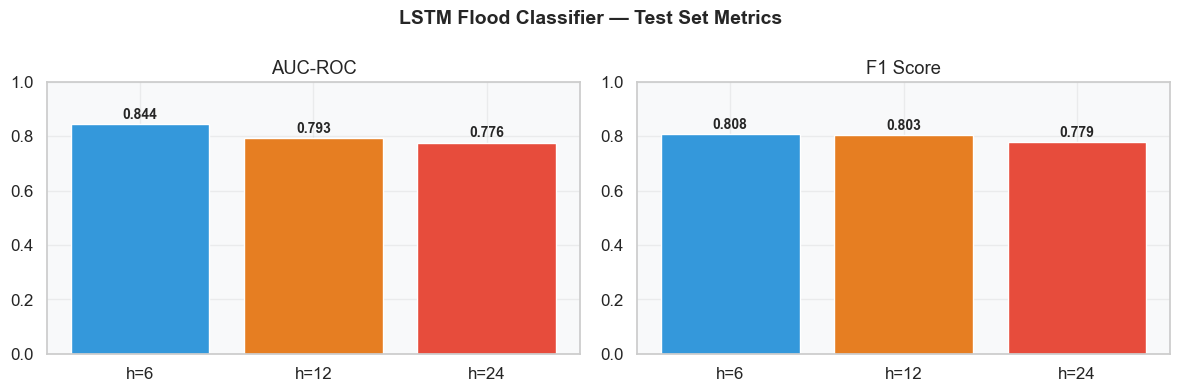

In [54]:
lstm_metrics = sql_query(conn, """
    SELECT horizon_hours, mae as auc, r2 as f1
    FROM ctl.ml_models
    WHERE algorithm = 'LSTM_Flood' AND estacao_sk = 229
    ORDER BY horizon_hours
""")

if len(lstm_metrics) > 0:
    lstm_metrics['csi'] = 0.0
    display(lstm_metrics.style.set_caption('LSTM Training Metrics (AUC / F1)'))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    horizons = sorted(lstm_metrics['horizon_hours'].unique())
    metric_cols = ['auc', 'f1']
    titles = ['AUC-ROC', 'F1 Score']
    colors_h = {6: '#3498db', 12: '#e67e22', 24: '#e74c3c'}

    for ax, col, title in zip(axes, metric_cols, titles):
        vals = [lstm_metrics[lstm_metrics['horizon_hours'] == h][col].values[0] for h in horizons]
        bars = ax.bar([f'h={h}' for h in horizons], vals,
                      color=[colors_h.get(h, '#888') for h in horizons])
        ax.set_title(title)
        ax.set_ylim(0, 1)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
                    ha='center', fontsize=10, fontweight='bold')

    plt.suptitle('LSTM Flood Classifier — Test Set Metrics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No LSTM metrics found in ctl.ml_models')

---
## Section 10: Risk Classification (v6)

BAIXO/MODERADO/ALTO/CRITICO categorical risk classification with weighted scoring.

In [55]:
risk_current = sql_query(conn, """
    SELECT rc.estacao_sk, e.estacao_nome, rc.nivel_risco, rc.categoria_risco,
           rc.nivel_inst_atual, rc.nivel_alerta, rc.risco_percentil,
           rc.taxa_subida_6h, rc.precip_accum_24h, rc.solo_saturacao_pct,
           rc.nivel_inst_pred_1h, rc.nivel_inst_pred_6h, rc.nivel_inst_pred_24h,
           rc.data_atualizacao
    FROM ml.flood_risk_current rc
    JOIN gold.dim_estacao e ON rc.estacao_sk = e.estacao_sk
    ORDER BY rc.nivel_risco DESC, rc.risco_percentil DESC
""")

if len(risk_current) > 0:
    print(f'Risk current: {len(risk_current)} stations')
    display(risk_current.style.set_caption('Current Flood Risk'))
else:
    print('No risk data. Run predict_now.py first.')

Risk current: 3 stations


,estacao_sk,estacao_nome,nivel_risco,categoria_risco,nivel_inst_atual,nivel_alerta,risco_percentil,taxa_subida_6h,precip_accum_24h,solo_saturacao_pct,nivel_inst_pred_1h,nivel_inst_pred_6h,nivel_inst_pred_24h,data_atualizacao
0,229,GEVIM (13H/04H),1,Muito Baixo,1.400000,BAIXO,0.000000,-0.003333,0.000000,0.000000,1.421819,1.428567,1.418733,2026-06-07 18:02:51.147000
1,232,MOINHOS DE PEPIM (10K/04H),1,Muito Baixo,1.160000,BAIXO,0.000000,0.000000,0.000000,0.000000,1.164580,1.160722,1.215129,2026-06-07 18:02:51.150000
2,233,PONTE CABOUCO (12G/02H),1,Muito Baixo,0.240000,BAIXO,0.000000,-0.003333,0.000000,0.000000,0.240113,0.235267,0.270390,2026-06-07 18:02:51.153000


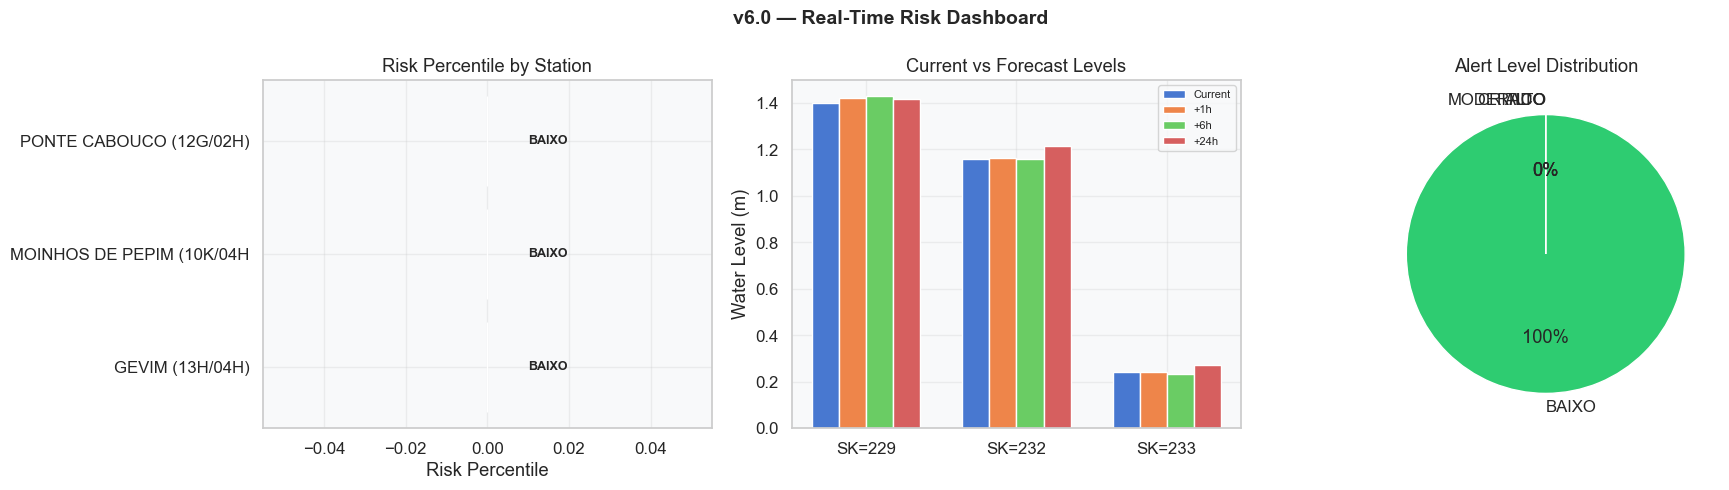

In [56]:
if len(risk_current) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    alert_colors = {'BAIXO': '#2ecc71', 'MODERADO': '#f39c12', 'ALTO': '#e74c3c', 'CRITICO': '#8b0000'}
    cat_colors = {'Muito Baixo': '#2ecc71', 'Baixo': '#27ae60', 'Moderado': '#f39c12',
                  'Alto': '#e74c3c', 'Muito Alto': '#8b0000'}

    bars = axes[0].barh(risk_current['estacao_nome'].str[:25], risk_current['risco_percentil'],
                        color=[alert_colors.get(a, '#888') for a in risk_current['nivel_alerta']])
    axes[0].set_xlabel('Risk Percentile')
    axes[0].set_title('Risk Percentile by Station')
    for bar, alert in zip(bars, risk_current['nivel_alerta']):
        axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     alert, va='center', fontsize=9, fontweight='bold')

    pred_cols = ['nivel_inst_atual', 'nivel_inst_pred_1h', 'nivel_inst_pred_6h', 'nivel_inst_pred_24h']
    pred_labels = ['Current', '+1h', '+6h', '+24h']
    x = np.arange(len(risk_current))
    width = 0.18
    for j, (col, lbl) in enumerate(zip(pred_cols, pred_labels)):
        if col in risk_current.columns:
            axes[1].bar(x + j * width, risk_current[col].fillna(0), width, label=lbl)
    axes[1].set_xticks(x + 1.5 * width)
    axes[1].set_xticklabels([f'SK={sk}' for sk in risk_current['estacao_sk']])
    axes[1].set_ylabel('Water Level (m)')
    axes[1].set_title('Current vs Forecast Levels')
    axes[1].legend(fontsize=8)

    alert_counts = risk_current['nivel_alerta'].value_counts()
    ac = alert_counts.reindex(['BAIXO', 'MODERADO', 'ALTO', 'CRITICO'], fill_value=0)
    axes[2].pie(ac, labels=ac.index, colors=[alert_colors[a] for a in ac.index],
                autopct='%1.0f%%', startangle=90)
    axes[2].set_title('Alert Level Distribution')

    plt.suptitle('v6.0 — Real-Time Risk Dashboard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Flood thresholds: 4 stations


,estacao_sk,p90,p95,p99,mean_nivel,std_nivel,max_nivel
0,229,2.180000,2.360000,2.840000,1.474034,0.545497,4.810000
1,232,1.610000,1.790000,2.170000,1.263643,0.279790,3.550000
2,233,0.720000,1.070000,2.080000,0.284813,0.435163,5.550000
3,234,2.770000,2.840000,2.920000,2.531796,0.205128,4.700000


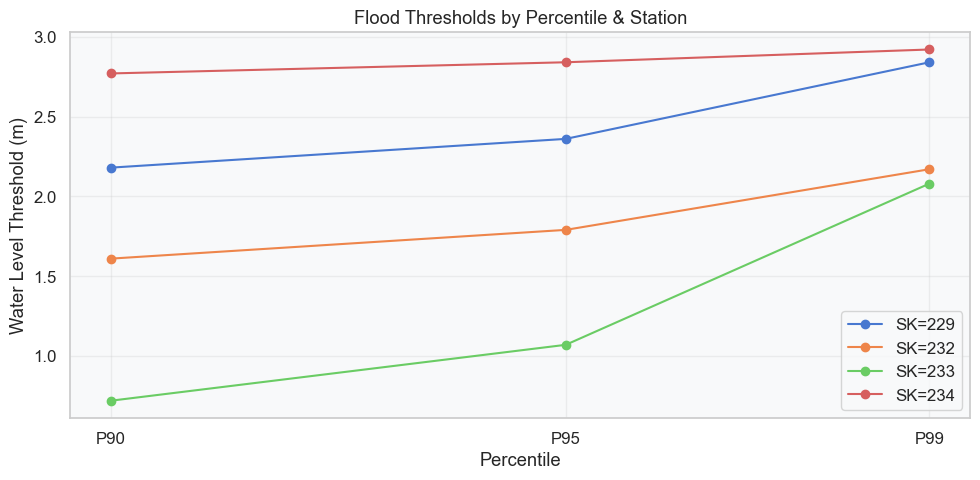

In [57]:
thresholds = sql_query(conn, """
    SELECT estacao_sk, p90, p95, p99, mean_nivel, std_nivel, max_nivel
    FROM ctl.flood_thresholds
    ORDER BY estacao_sk
""")

if len(thresholds) > 0:
    print(f'Flood thresholds: {len(thresholds)} stations')
    display(thresholds.style.set_caption('Flood Thresholds (m)'))

    fig, ax = plt.subplots(figsize=(10, 5))
    x = [90, 95, 99]
    for _, row in thresholds.iterrows():
        ax.plot(x, [row['p90'], row['p95'], row['p99']], marker='o', label=f'SK={int(row["estacao_sk"])}')
    ax.set_xlabel('Percentile')
    ax.set_ylabel('Water Level Threshold (m)')
    ax.set_title('Flood Thresholds by Percentile & Station')
    ax.set_xticks(x)
    ax.set_xticklabels(['P90', 'P95', 'P99'])
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No flood thresholds found. Run flood_labeling.py first.')


### Extra Visualizations

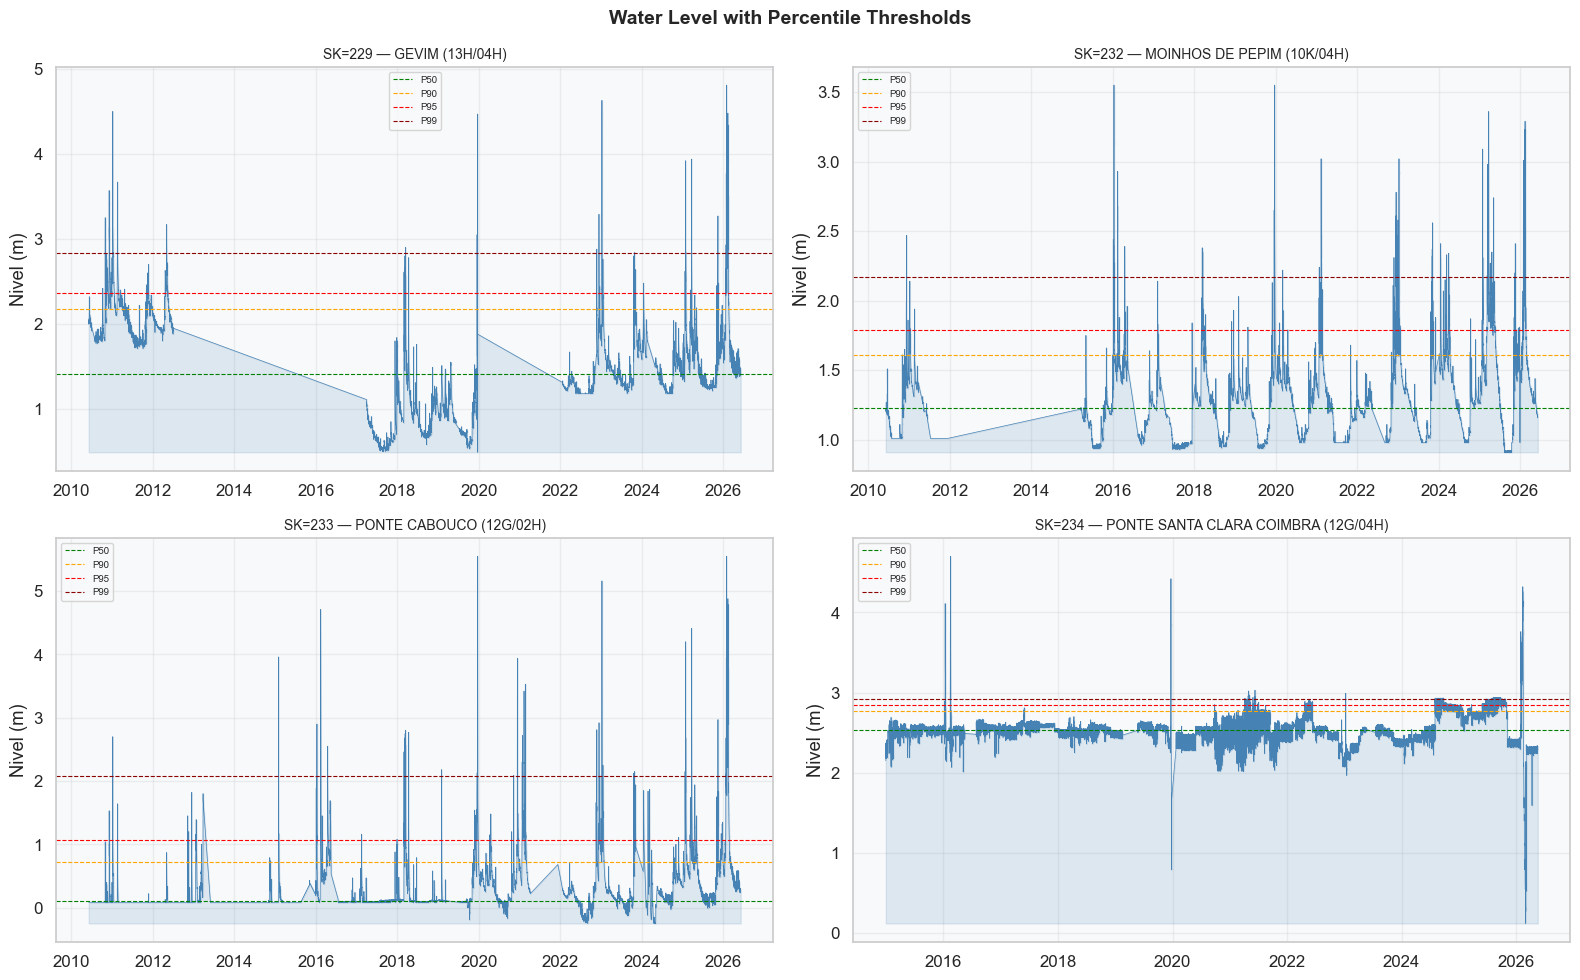

In [58]:
raw['data_hora'] = pd.to_datetime(raw['data_hora'])
raw.dropna(subset=['valor'], inplace=True)

if 'station_stats' not in dir() or not station_stats:
    station_stats = {}
    for sk in NATURAL_STATIONS:
        col = None
        for c in df_features.columns:
            if str(sk) in c and 'NIVEL_INST' in c.upper():
                col = c
                break
        if col is None:
            continue
        s = df_features.loc[df_features['estacao_sk'] == sk, col].dropna()
        if len(s) < 100:
            continue
        station_stats[sk] = {
            'mean': float(s.mean()), 'std': float(s.std()),
            'p50': float(s.quantile(0.50)), 'p75': float(s.quantile(0.75)),
            'p90': float(s.quantile(0.90)), 'p95': float(s.quantile(0.95)),
            'p99': float(s.quantile(0.99)), 'min': float(s.min()),
            'max': float(s.max())
        }

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

nivel_raw = raw[raw['parametro_codigo'] == '1843']
for i, sk in enumerate(NATURAL_STATIONS):
    ax = axes[i // 2][i % 2]
    st = nivel_raw[nivel_raw['estacao_sk'] == sk].sort_values('data_hora')
    if len(st) == 0:
        continue
    ax.plot(st['data_hora'], st['valor'], linewidth=0.5, color='steelblue')
    ax.fill_between(st['data_hora'], st['valor'].min(), st['valor'], alpha=0.15, color='steelblue')
    stats = station_stats.get(sk, {})
    if stats:
        ax.axhline(stats.get('p50', 0), color='green', linestyle='--', linewidth=0.8, label='P50')
        ax.axhline(stats.get('p90', 0), color='orange', linestyle='--', linewidth=0.8, label='P90')
        ax.axhline(stats.get('p95', 0), color='red', linestyle='--', linewidth=0.8, label='P95')
        ax.axhline(stats.get('p99', 0), color='darkred', linestyle='--', linewidth=0.8, label='P99')
    name = st['estacao_nome'].iloc[0] if len(st) > 0 else f'SK={sk}'
    ax.set_title(f'SK={sk} — {name}', fontsize=10)
    ax.set_ylabel('Nivel (m)')
    ax.legend(fontsize=7)

plt.suptitle('Water Level with Percentile Thresholds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


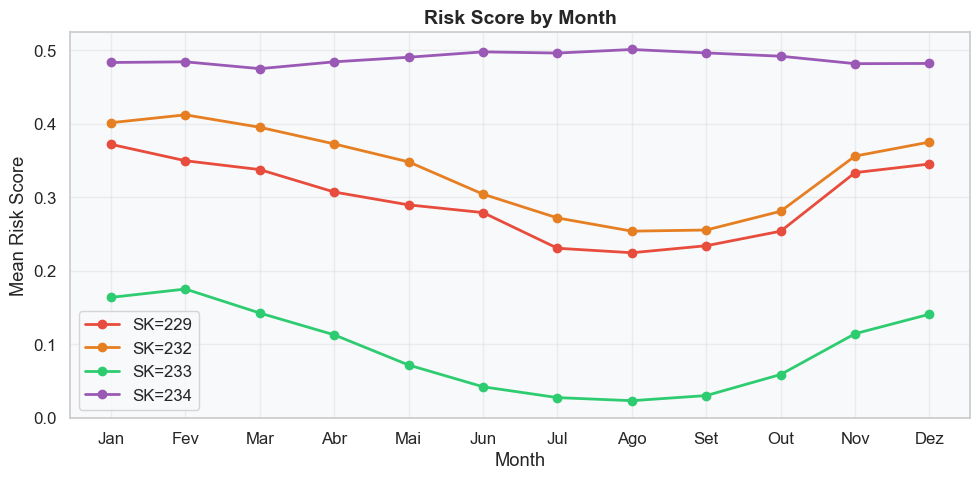

In [61]:
if 'km_cluster' in risk_df.columns and len(risk_df) > 0:
    monthly_risk = risk_df.groupby(
        [risk_df['data_hora'].dt.month.rename('month'), 'estacao_sk']
    )['risco_combinado'].mean().unstack('estacao_sk')

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = {229: '#e74c3c', 232: '#e67e22', 233: '#2ecc71', 234: '#9b59b6'}
    for sk in monthly_risk.columns:
        ax.plot(monthly_risk.index, monthly_risk[sk], marker='o',
                color=colors.get(sk, '#888'), linewidth=2, label=f'SK={sk}')

    ax.set_xlabel('Month')
    ax.set_ylabel('Mean Risk Score')
    ax.set_title('Risk Score by Month', fontsize=14, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

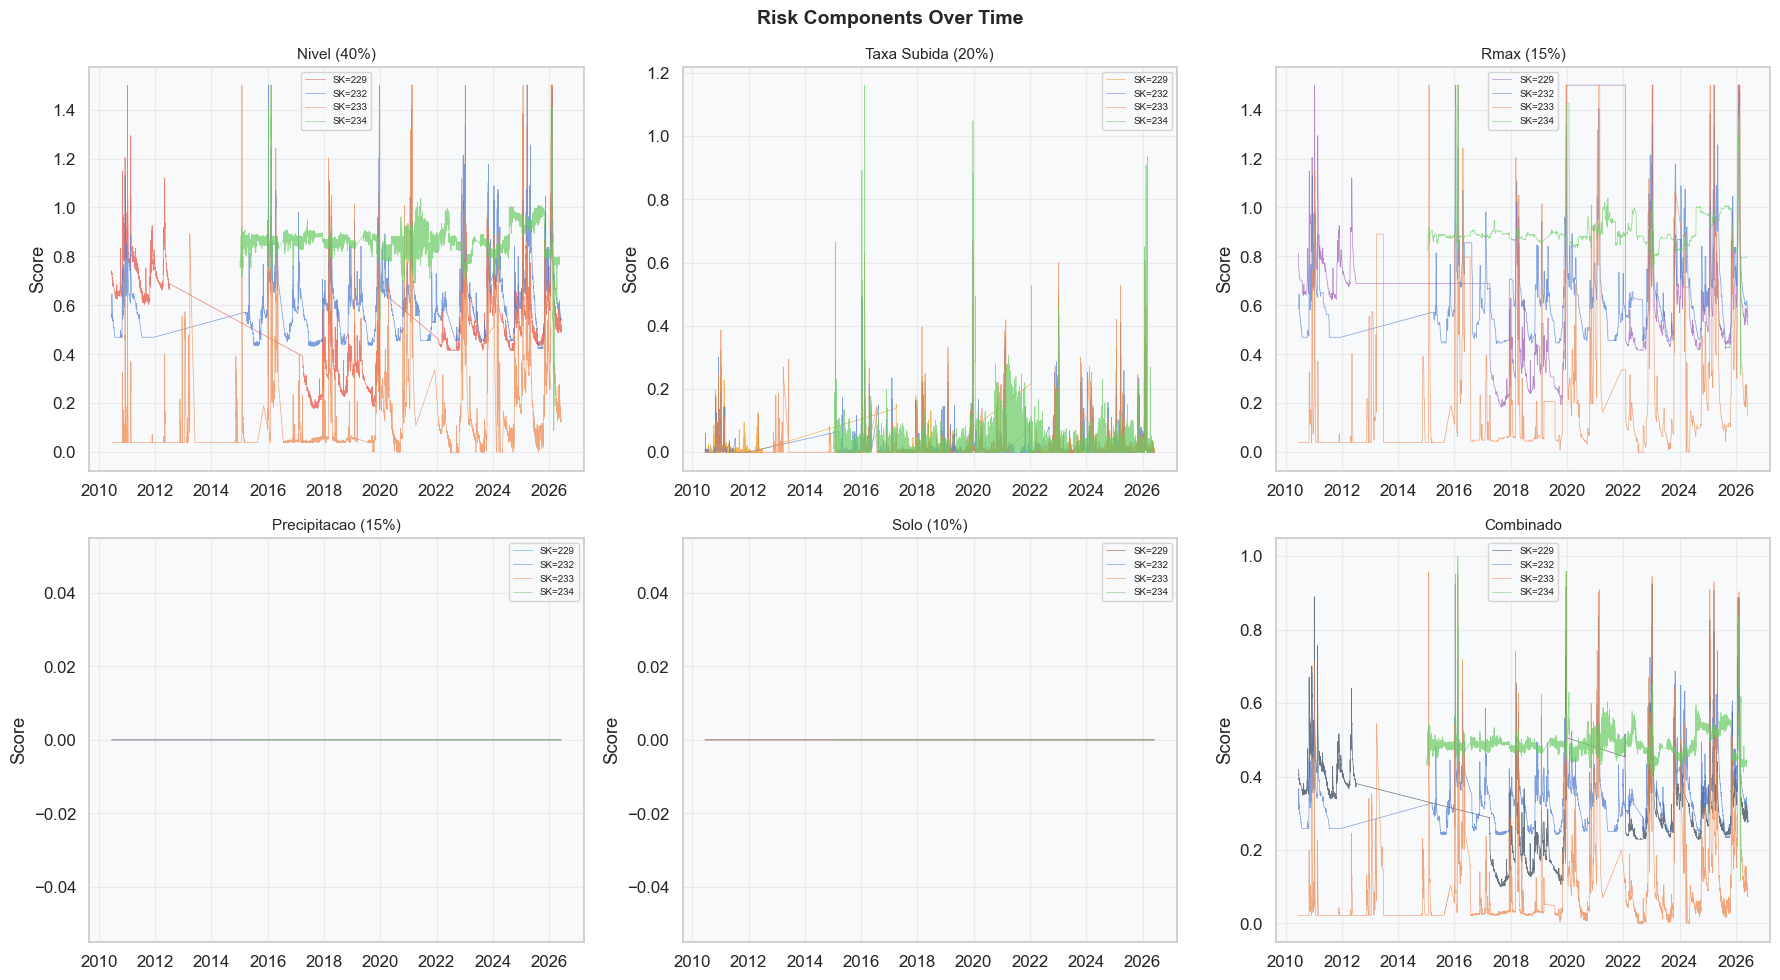

In [63]:
risk_df['risco_nivel'] = nivel_rel
risk_df['risco_taxa'] = taxa_rel
risk_df['risco_rmax'] = rmax_rel
risk_df['risco_precipitacao'] = precip_risk
risk_df['risco_solo'] = soil_risk

if 'km_cluster' in risk_df.columns:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    risk_components = ['risco_nivel', 'risco_taxa', 'risco_rmax', 'risco_precipitacao', 'risco_solo', 'risco_combinado']
    comp_names = ['Nivel (40%)', 'Taxa Subida (20%)', 'Rmax (15%)', 'Precipitacao (15%)', 'Solo (10%)', 'Combinado']
    colors_comp = ['#e74c3c', '#f39c12', '#9b59b6', '#3498db', '#8B4513', '#2c3e50']

    for i, (comp, name, color) in enumerate(zip(risk_components, comp_names, colors_comp)):
        ax = axes[i // 3][i % 3]
        if comp in risk_df.columns:
            for sk in NATURAL_STATIONS:
                mask = risk_df['estacao_sk'] == sk
                st = risk_df[mask].sort_values('data_hora')
                ax.plot(st['data_hora'], st[comp], linewidth=0.5, alpha=0.7, label=f'SK={sk}', color=color if sk == NATURAL_STATIONS[0] else None)
        ax.set_title(name, fontsize=11)
        ax.set_ylabel('Score')
        ax.legend(fontsize=7)

    plt.suptitle('Risk Components Over Time', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

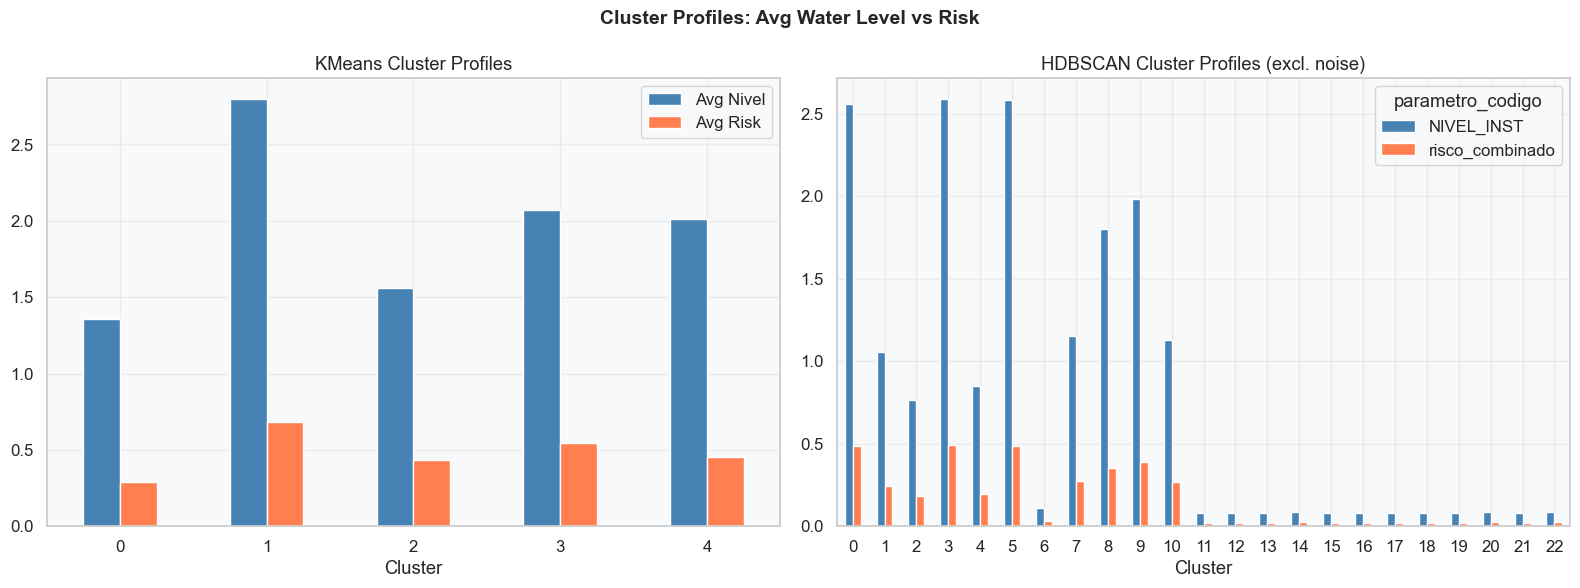

In [64]:
if 'km_cluster' in risk_df.columns and 'hdb_cluster' in risk_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    km_profile = risk_df.groupby('km_cluster')[['NIVEL_INST', 'risco_combinado']].mean()
    km_profile.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
    axes[0].set_title('KMeans Cluster Profiles')
    axes[0].set_xlabel('Cluster')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(['Avg Nivel', 'Avg Risk'])

    hdb_valid = risk_df[risk_df['hdb_cluster'] != -1]
    if len(hdb_valid) > 0:
        hdb_profile = hdb_valid.groupby('hdb_cluster')[['NIVEL_INST', 'risco_combinado']].mean()
        hdb_profile.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
        axes[1].set_title('HDBSCAN Cluster Profiles (excl. noise)')
        axes[1].set_xlabel('Cluster')
        axes[1].tick_params(axis='x', rotation=0)
    else:
        axes[1].text(0.5, 0.5, 'No HDBSCAN clusters', transform=axes[1].transAxes,
                     ha='center', fontsize=14)

    plt.suptitle('Cluster Profiles: Avg Water Level vs Risk', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

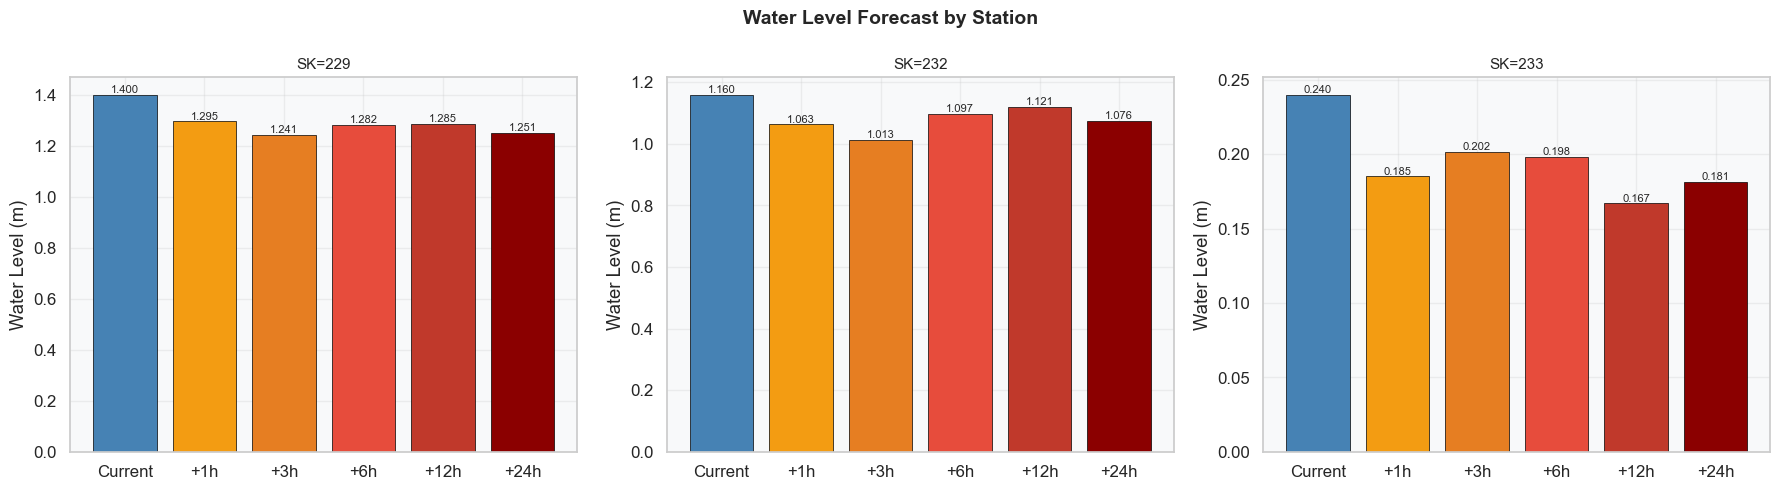

In [65]:
if len(pred_df) > 0:
    fig, axes = plt.subplots(1, len(pred_df), figsize=(6 * len(pred_df), 5))
    if len(pred_df) == 1:
        axes = [axes]

    for i, (_, row) in enumerate(pred_df.iterrows()):
        ax = axes[i]
        sk = row['estacao_sk']
        niveis = [row['latest_nivel']] + [row.get(f'pred_{h}h', 0) for h in FORECAST_HORIZONS]
        labels = ['Current'] + [f'+{h}h' for h in FORECAST_HORIZONS]
        colors_pred = ['steelblue'] + ['#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#8b0000']

        bars = ax.bar(labels, niveis, color=colors_pred[:len(niveis)], edgecolor='black', linewidth=0.5)
        ax.set_title(f'SK={sk}', fontsize=11)
        ax.set_ylabel('Water Level (m)')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    plt.suptitle('Water Level Forecast by Station', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

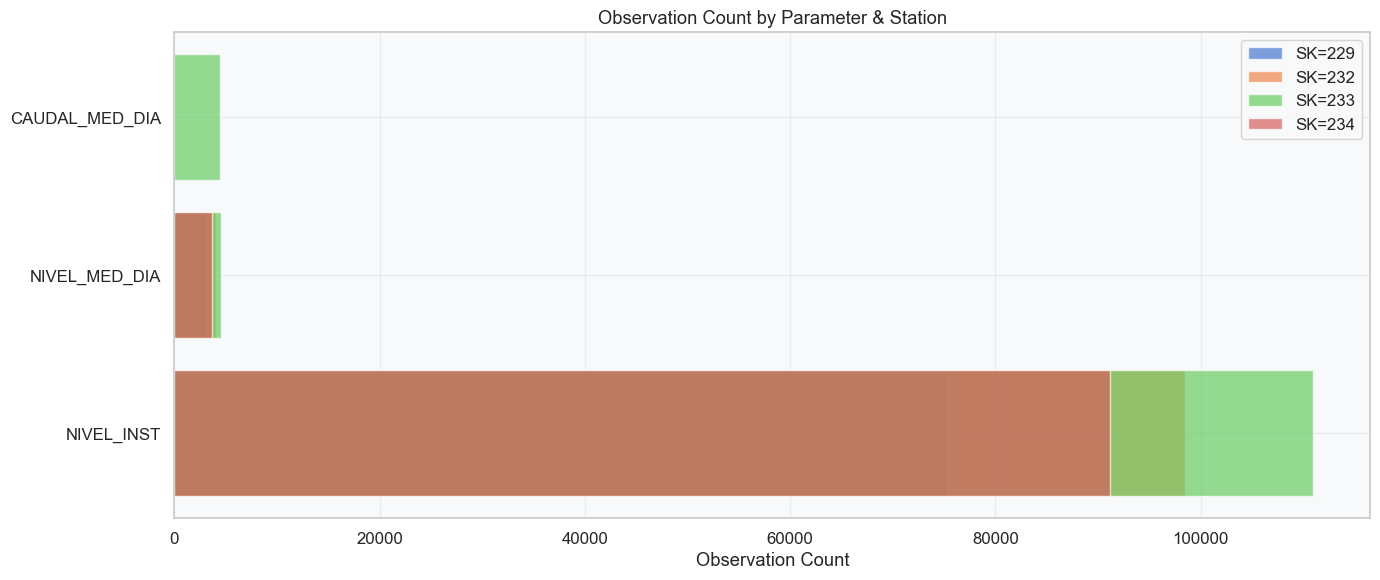

In [66]:
station_facts = sql_query(conn, """
    SELECT e.estacao_sk, e.estacao_nome, e.sistema_origem,
           p.parametro_codigo, COUNT(*) as cnt,
           AVG(f.valor) as avg_val, MIN(f.valor) as min_val, MAX(f.valor) as max_val
    FROM gold.fact_medicao f
    JOIN gold.dim_estacao e ON f.estacao_sk = e.estacao_sk
    JOIN gold.dim_parametro p ON f.parametro_sk = p.parametro_sk
    WHERE e.estacao_sk IN (""" + ','.join(['?'] * len(NATURAL_STATIONS)) + """)
    GROUP BY e.estacao_sk, e.estacao_nome, e.sistema_origem, p.parametro_codigo
    ORDER BY e.estacao_sk, p.parametro_codigo
""", NATURAL_STATIONS)

fig, ax = plt.subplots(figsize=(14, 6))
for sk in NATURAL_STATIONS:
    mask = station_facts['estacao_sk'] == sk
    sf = station_facts[mask]
    ax.barh(sf['parametro_codigo'].map(PARAM_ALIAS).fillna(sf['parametro_codigo']),
            sf['cnt'], label=f'SK={sk}', alpha=0.7)

ax.set_xlabel('Observation Count')
ax.set_title('Observation Count by Parameter & Station')
ax.legend()
plt.tight_layout()
plt.show()

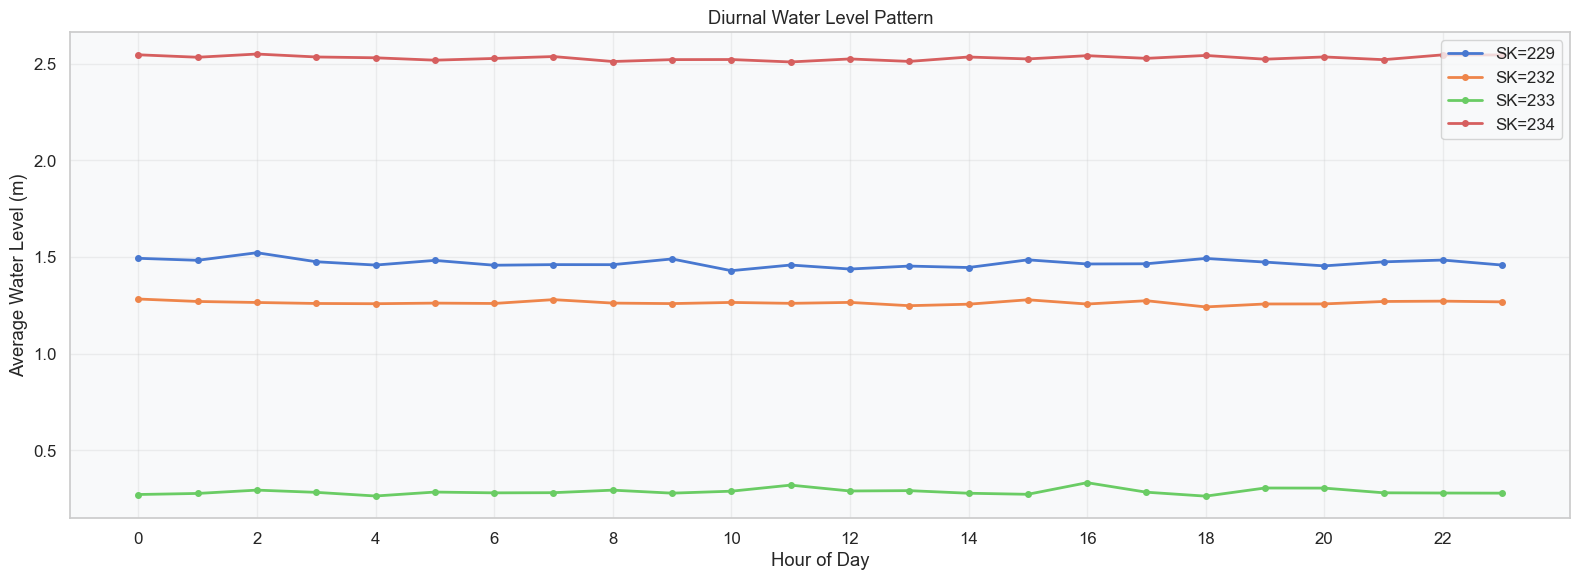

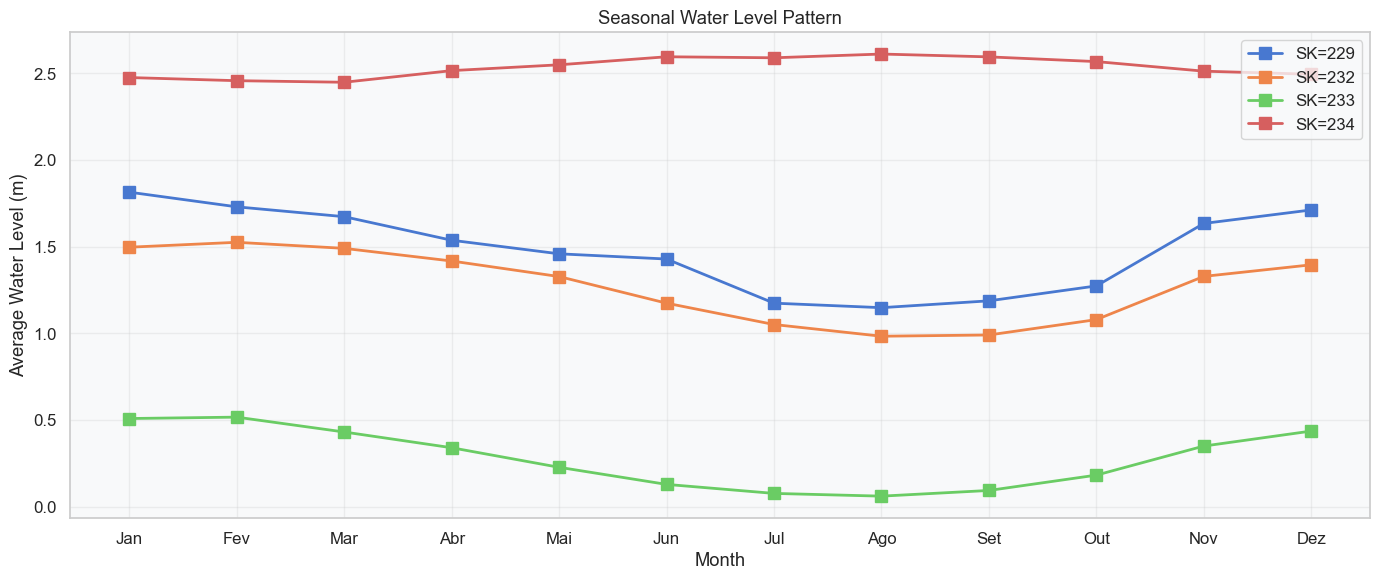

In [67]:
if 'NIVEL_INST' in pivot.columns:
    fig, ax = plt.subplots(figsize=(16, 6))

    for sk in NATURAL_STATIONS:
        mask = pivot['estacao_sk'] == sk
        st = pivot[mask].sort_values('data_hora')
        if 'NIVEL_INST' in st.columns and len(st) > 0:
            hourly_avg = st.groupby('hora')['NIVEL_INST'].mean()
            ax.plot(hourly_avg.index, hourly_avg.values, marker='o', markersize=4,
                    label=f'SK={sk}', linewidth=2)

    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Average Water Level (m)')
    ax.set_title('Diurnal Water Level Pattern')
    ax.set_xticks(range(0, 24, 2))
    ax.legend()
    plt.tight_layout()
    plt.show()

if 'NIVEL_INST' in pivot.columns:
    fig, ax = plt.subplots(figsize=(14, 6))

    for sk in NATURAL_STATIONS:
        mask = pivot['estacao_sk'] == sk
        st = pivot[mask].sort_values('data_hora')
        if 'NIVEL_INST' in st.columns and len(st) > 0:
            monthly_avg = st.groupby('mes')['NIVEL_INST'].mean()
            ax.plot(monthly_avg.index, monthly_avg.values, marker='s', markersize=8,
                    label=f'SK={sk}', linewidth=2)

    ax.set_xlabel('Month')
    ax.set_ylabel('Average Water Level (m)')
    ax.set_title('Seasonal Water Level Pattern')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
    ax.legend()
    plt.tight_layout()
    plt.show()

In [69]:
# quar = sql_query(conn, """
#     SELECT Fonte, Motivo, COUNT(*) as total,
#            MIN(Dt_Quarentena) as primeira, MAX(Dt_Quarentena) as ultima
#     FROM quarentena.ETL_Quarentena
#     GROUP BY Fonte, Motivo
#     ORDER BY total DESC
# """)

# if len(quar) > 0:
#     fig, ax = plt.subplots(figsize=(12, max(4, len(quar) * 0.5)))
#     quar['label'] = quar['Fonte'] + ' — ' + quar['Motivo'].str[:50]
#     ax.barh(quar['label'], quar['total'], color='coral', edgecolor='black', linewidth=0.3)
#     ax.set_xlabel('Rejected Records')
#     ax.set_title('Quarentena: Rejected Records by Source & Reason')
#     for i, v in enumerate(quar['total']):
#         ax.text(v + quar['total'].max() * 0.01, i, f'{v:,}', va='center', fontsize=9)
#     plt.tight_layout()
#     plt.show()

# conn.close()
# print('Notebook finished - connection closed.')

[1/5] Loading SNIRH level data...
  SNIRH: 2905 hours, stations: [232, 233, 234]
[2/5] Loading ERA5 data...
  ERA5: 2905 hours
[3/5] Loading flood thresholds...
[4/5] Loading LSTM models...
  h=6: loaded (threshold=0.1000)
  h=12: loaded (threshold=0.1000)
  h=24: loaded (threshold=0.1000)
[5/5] Running backtest...
  SK=229: insufficient data
  SK=232 h=6: 929/2857 alerts (32.5%), max_prob=0.9877
  SK=232 h=12: 1437/2857 alerts (50.3%), max_prob=0.9717
  SK=232 h=24: 1655/2857 alerts (57.9%), max_prob=0.9747
  SK=233 h=6: 668/2857 alerts (23.4%), max_prob=0.9873
  SK=233 h=12: 1055/2857 alerts (36.9%), max_prob=0.9745
  SK=233 h=24: 1460/2857 alerts (51.1%), max_prob=0.9704

Backtest: Cheia Janeiro-Fevereiro 2016 — 17142 predictions


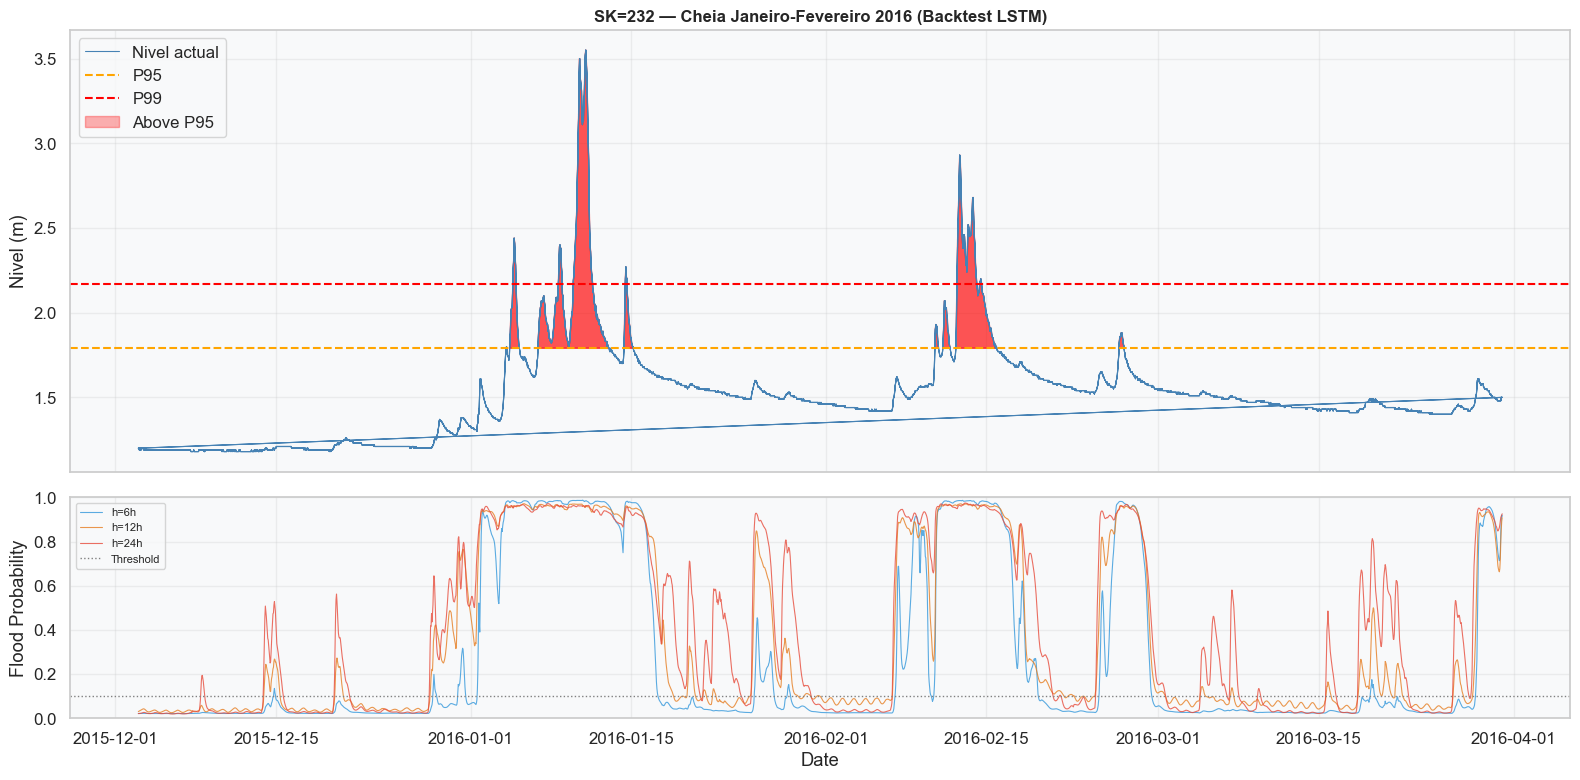

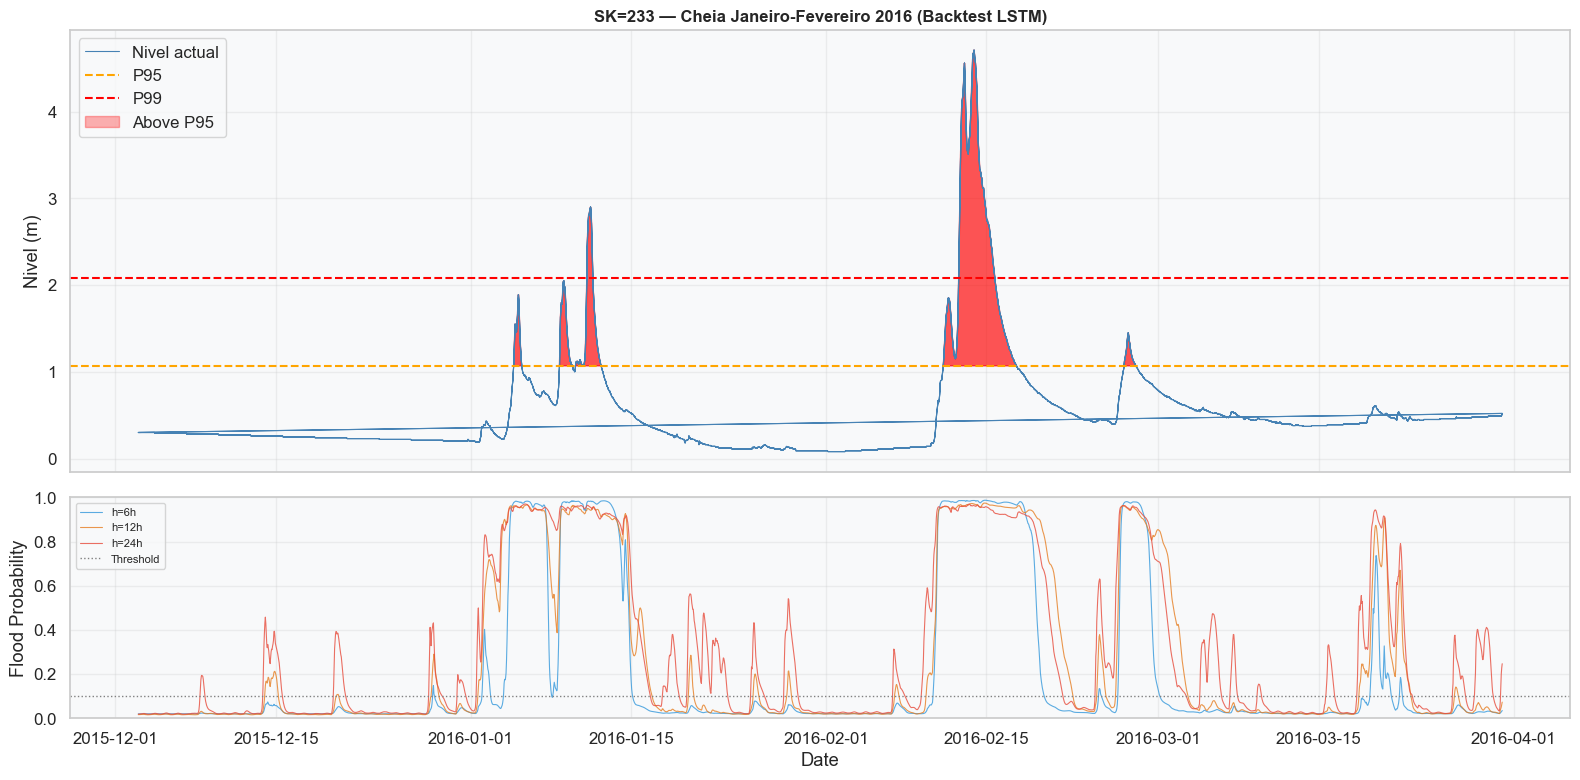

,estacao_sk,horizon,max_prob,mean_prob,n_alerts,total,max_nivel,alert_pct
0,232,6,0.987653,0.267801,929,2857,3.550000,32.516626
1,232,12,0.971703,0.342183,1437,2857,3.550000,50.297515
2,232,24,0.974718,0.396323,1655,2857,3.550000,57.927896
3,233,6,0.987317,0.203436,668,2857,4.710000,23.381169
4,233,12,0.974507,0.266551,1055,2857,4.710000,36.926846
5,233,24,0.970412,0.313537,1460,2857,4.710000,51.102555


In [76]:
BACKTEST_EVENT = {
    'name': 'Cheia Janeiro-Fevereiro 2016',
    'start': '2015-12-01',
    'end': '2016-03-31',
    'peak': '2016-02-12',
}

LSTM_FEATURES_BT = [
    'nivel', 'nivel_lag_1h', 'nivel_lag_3h', 'nivel_lag_6h',
    'nivel_delta_1h', 'nivel_delta_3h', 'nivel_delta_6h',
    'nivel_rmean_6h', 'nivel_rmean_24h', 'nivel_rstd_24h',
    'era5_precip', 'era5_precip_accum_6h', 'era5_precip_accum_24h',
    'era5_temp', 'era5_soil_l1', 'era5_pressure',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
]
LOOKBACK = 48

LSTM_DIR = os.path.join(MODELS_DIR, 'lstm')
HORIZONS = [6, 12, 24]

prox_rows = sql_query(conn, """
    SELECT source_station_sk, target_station_sk
    FROM ctl.map_spatial_proximity
    WHERE is_nearest = 1 AND source_station_sk IN (229,232,233,234)
""")
prox_map_bt = {r['source_station_sk']: r['target_station_sk'] for _, r in prox_rows.iterrows()}

print('[1/5] Loading SNIRH level data...')
snirh_bt = sql_query(conn, """
    SELECT e.estacao_sk, t.data_hora, f.valor
    FROM gold.fact_medicao f
    JOIN gold.dim_estacao e ON f.estacao_sk = e.estacao_sk
    JOIN gold.dim_tempo t ON f.tempo_sk = t.tempo_sk
    JOIN gold.dim_parametro p ON f.parametro_sk = p.parametro_sk
    WHERE e.estacao_sk IN (229,232,233,234)
      AND p.parametro_codigo = '1843'
      AND t.data_hora BETWEEN '{}' AND '{}'
    ORDER BY e.estacao_sk, t.data_hora
""".format(BACKTEST_EVENT['start'], BACKTEST_EVENT['end']))

snirh_pivot = snirh_bt.pivot_table(index='data_hora', columns='estacao_sk', values='valor', aggfunc='first')
snirh_pivot.index = pd.to_datetime(snirh_pivot.index)
snirh_pivot = snirh_pivot.resample('1h').last().ffill()
print('  SNIRH: {} hours, stations: {}'.format(len(snirh_pivot), list(snirh_pivot.columns)))

print('[2/5] Loading ERA5 data...')
era5_sks = list(set(prox_map_bt.values()))
sk_ph = ','.join(str(s) for s in era5_sks)
era5_bt = sql_query(conn, """
    SELECT e.estacao_sk, t.data_hora, p.parametro_codigo, f.valor
    FROM gold.fact_medicao f
    JOIN gold.dim_estacao e ON f.estacao_sk = e.estacao_sk
    JOIN gold.dim_tempo t ON f.tempo_sk = t.tempo_sk
    JOIN gold.dim_parametro p ON f.parametro_sk = p.parametro_sk
    WHERE e.estacao_sk IN ({})
      AND p.parametro_codigo IN ('tp','t2m','swvl1','sp')
      AND t.data_hora BETWEEN '{}' AND '{}'
    ORDER BY e.estacao_sk, t.data_hora
""".format(sk_ph, BACKTEST_EVENT['start'], BACKTEST_EVENT['end']))

era5_pivot = era5_bt.pivot_table(index='data_hora', columns=['estacao_sk','parametro_codigo'], values='valor', aggfunc='first')
era5_pivot.index = pd.to_datetime(era5_pivot.index)
era5_pivot = era5_pivot.resample('1h').last().ffill()
print('  ERA5: {} hours'.format(len(era5_pivot)))

print('[3/5] Loading flood thresholds...')
thresholds_bt = sql_query(conn, """
    SELECT estacao_sk, p95, p99 FROM ctl.flood_thresholds
""")
p95_map = {r['estacao_sk']: r['p95'] for _, r in thresholds_bt.iterrows()}
p99_map = {r['estacao_sk']: r['p99'] for _, r in thresholds_bt.iterrows()}

print('[4/5] Loading LSTM models...')
models_bt = {}
scalers_bt = {}
configs_bt = {}
for h in HORIZONS:
    mp = os.path.join(LSTM_DIR, 'lstm_flood_h{}.keras'.format(h))
    sp = os.path.join(LSTM_DIR, 'scaler_h{}.pkl'.format(h))
    cp = os.path.join(LSTM_DIR, 'config_h{}.json'.format(h))
    if os.path.exists(mp):
        models_bt[h] = keras.models.load_model(mp)
        with open(sp, 'rb') as f:
            scalers_bt[h] = pickle.load(f)
        with open(cp, 'r') as f:
            configs_bt[h] = json.load(f)
        print('  h={}: loaded (threshold={:.4f})'.format(h, configs_bt[h]['threshold']))

print('[5/5] Running backtest...')

def build_lstm_features_bt(sk, snirh_pivot, era5_pivot, prox_map_bt):
    if sk not in snirh_pivot.columns:
        return None
    nivel = snirh_pivot[sk].dropna()
    if len(nivel) < LOOKBACK:
        return None

    df = pd.DataFrame(index=nivel.index)
    df['nivel'] = nivel
    df['nivel_lag_1h'] = df['nivel'].shift(1)
    df['nivel_lag_3h'] = df['nivel'].shift(3)
    df['nivel_lag_6h'] = df['nivel'].shift(6)
    df['nivel_delta_1h'] = df['nivel'] - df['nivel'].shift(1)
    df['nivel_delta_3h'] = df['nivel'] - df['nivel'].shift(3)
    df['nivel_delta_6h'] = df['nivel'] - df['nivel'].shift(6)
    df['nivel_rmean_6h'] = df['nivel'].rolling(6, min_periods=1).mean()
    df['nivel_rmean_24h'] = df['nivel'].rolling(24, min_periods=1).mean()
    df['nivel_rstd_24h'] = df['nivel'].rolling(24, min_periods=1).std()

    era5_sk = prox_map_bt.get(sk)
    if era5_sk and era5_sk in [c[0] for c in era5_pivot.columns]:
        for param_code, col_name in [('tp','era5_precip'),('t2m','era5_temp'),('swvl1','era5_soil_l1'),('sp','era5_pressure')]:
            key = (era5_sk, param_code)
            if key in era5_pivot.columns:
                df[col_name] = era5_pivot[key].reindex(df.index).ffill()

    if 'era5_precip' in df.columns:
        df['era5_precip_accum_6h'] = df['era5_precip'].rolling(6, min_periods=1).sum()
        df['era5_precip_accum_24h'] = df['era5_precip'].rolling(24, min_periods=1).sum()

    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

    for col in LSTM_FEATURES_BT:
        if col not in df.columns:
            df[col] = 0.0
    return df[LSTM_FEATURES_BT].ffill().fillna(0)

bt_results = []
for sk in [229, 232, 233]:
    feats = build_lstm_features_bt(sk, snirh_pivot, era5_pivot, prox_map_bt)
    if feats is None:
        print('  SK={}: insufficient data'.format(sk))
        continue

    nivel_actual = snirh_pivot[sk].reindex(feats.index)

    for h in HORIZONS:
        if h not in models_bt:
            continue
        model = models_bt[h]
        scaler = scalers_bt[h]
        threshold = configs_bt[h]['threshold']

        probs = []
        timestamps = []
        for i in range(LOOKBACK, len(feats)):
            window = feats.iloc[i-LOOKBACK:i].values
            window_scaled = scaler.transform(window).reshape(1, LOOKBACK, len(LSTM_FEATURES_BT))
            prob = float(model.predict(window_scaled, verbose=0).flatten()[0])
            probs.append(prob)
            timestamps.append(feats.index[i])

        for ts, prob in zip(timestamps, probs):
            bt_results.append({
                'estacao_sk': sk, 'horizon': h, 'data_hora': ts,
                'prob_cheia': prob, 'flood_alert': int(prob >= threshold),
                'nivel': nivel_actual.get(ts, np.nan),
                'p95': p95_map.get(sk, 0),
            })

        n_alert = sum(1 for _, p in zip(timestamps, probs) if p >= threshold)
        print('  SK={} h={}: {}/{} alerts ({:.1f}%), max_prob={:.4f}'.format(
            sk, h, n_alert, len(probs), 100*n_alert/max(len(probs),1), max(probs)))

bt_df = pd.DataFrame(bt_results)

if len(bt_df) > 0:
    print('\nBacktest: {} — {} predictions'.format(BACKTEST_EVENT['name'], len(bt_df)))

    colors_h = {6: '#3498db', 12: '#e67e22', 24: '#e74c3c'}
    for sk in [229, 232, 233]:
        sk_data = bt_df[bt_df['estacao_sk'] == sk]
        if len(sk_data) == 0:
            continue

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                        gridspec_kw={'height_ratios': [2, 1]})

        ax1.plot(sk_data['data_hora'], sk_data['nivel'], color='steelblue', linewidth=0.8, label='Nivel actual')
        ax1.axhline(p95_map.get(sk, 0), color='orange', linestyle='--', linewidth=1.5, label='P95')
        ax1.axhline(p99_map.get(sk, 0), color='red', linestyle='--', linewidth=1.5, label='P99')
        flood_mask = sk_data['nivel'] > p95_map.get(sk, 0)
        if flood_mask.any():
            ax1.fill_between(sk_data['data_hora'], sk_data['nivel'],
                            p95_map.get(sk, 0), where=flood_mask,
                            alpha=0.3, color='red', label='Above P95')
        ax1.set_ylabel('Nivel (m)')
        ax1.set_title('SK={} — {} (Backtest LSTM)'.format(sk, BACKTEST_EVENT['name']),
                      fontsize=12, fontweight='bold')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        for h in HORIZONS:
            h_data = sk_data[sk_data['horizon'] == h]
            if len(h_data) == 0:
                continue
            th = configs_bt[h]['threshold']
            ax2.plot(h_data['data_hora'], h_data['prob_cheia'],
                    color=colors_h[h], linewidth=0.8, alpha=0.8, label='h={}h'.format(h))
        ax2.axhline(configs_bt[HORIZONS[0]]['threshold'], color='gray', linestyle=':', linewidth=1, label='Threshold')
        ax2.set_ylabel('Flood Probability')
        ax2.set_xlabel('Date')
        ax2.set_ylim(0, 1)
        ax2.legend(loc='upper left', fontsize=8)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    summary = bt_df.groupby(['estacao_sk', 'horizon']).agg(
        max_prob=('prob_cheia', 'max'),
        mean_prob=('prob_cheia', 'mean'),
        n_alerts=('flood_alert', 'sum'),
        total=('flood_alert', 'count'),
        max_nivel=('nivel', 'max'),
    ).reset_index()
    summary['alert_pct'] = summary['n_alerts'] / summary['total'] * 100
    display(summary.style.set_caption('Backtest Summary: {}'.format(BACKTEST_EVENT['name'])))